In [1]:
import gzip
import pickle 
import matplotlib
matplotlib.rc('font', size=15)
import torch 
import pandas as pd
import numpy as np
import plotly.express as px
import sys
sys.path.append("/afs/cern.ch/work/m/mgarciam/private/mlpf/")
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

/afs/cern.ch/work/m/mgarciam/private/miniconda/miniconda3/envs/graphgps0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
import matplotlib
import sys
import os
from src.utils.inference.per_particle_metrics import plot_per_energy_resolution, reco_hist, \
    plot_mass_contribution_per_category, plot_mass_contribution_per_PID
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import mplhep as hep
from src.utils.inference.pandas_helpers import open_mlpf_dataframe, concat_with_batch_fix
from src.utils.inference.per_particle_metrics import (
    plot_per_energy_resolution2_multiple, plot_confusion_matrix, plot_confusion_matrix_pandora
    , calc_unit_circle_dist, plot_per_energy_resolution2, analyze_fakes, analyze_fakes_PID,
    plot_cm_per_energy, plot_fake_and_missed_energy_regions, quick_plot_mass,
    plot_cm_per_energy_on_overview
)
from src.utils.inference.efficiency_calc_and_plots import plot_efficiency_all
from src.utils.inference.track_cluster_eff_plots import plot_track_assignation_eval
from src.utils.inference.event_Ks import get_decay_type
import matplotlib.pyplot as plt
import torch
import pickle
from src.evaluation.refactor.preprocess import preprocess_dataframe, renumber_batch_idx
hep.style.use("CMS")
font = {'size': 10}
matplotlib.rc('font', **font)
import argparse

In [ ]:
PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

dir_top = "/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/"

sd_hgb1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_800_10000_0_None.pt"), False, False)
sd_hgb2, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_100_4000_0_None.pt"), False, False)
sd_hgb3, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_400_6000_0_None.pt"), False, False)
sd_hgb4, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_600_8000_0_None.pt"), False, False)
sd_hgb = concat_with_batch_fix([sd_hgb1, sd_hgb2, sd_hgb3,sd_hgb4 ])

sd_pandora1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_800_10000_0_None_pandora.pt"), False, False)
sd_pandora2, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_100_4000_0_None_pandora.pt"), False, False)
sd_pandora3, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_400_6000_0_None_pandora.pt"), False, False)
sd_pandora4, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_600_8000_0_None_pandora.pt"), False, False)
sd_pandora = concat_with_batch_fix([sd_pandora1, sd_pandora2, sd_pandora3, sd_pandora4])

# sd_hgb, sd_pandora = preprocess_dataframe(sd_hgb, sd_pandora, "")

mask = (sd_hgb.pred_pid_matched==4)*(sd_hgb.calibrated_E<1.5)
sd_hgb.loc[mask, "pred_pid_matched"]=1

In [14]:



PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

dir_top = "/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/"

sd_hgb1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_800_10000_0_None.pt"), False, False)
sd_hgb2, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_100_4000_0_None.pt"), False, False)
sd_hgb3, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_400_6000_0_None.pt"), False, False)
sd_hgb4, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_600_8000_0_None.pt"), False, False)
sd_hgb = concat_with_batch_fix([sd_hgb1, sd_hgb2, sd_hgb3,sd_hgb4 ])

sd_pandora1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_800_10000_0_None_pandora.pt"), False, False)
sd_pandora2, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_100_4000_0_None_pandora.pt"), False, False)
sd_pandora3, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_400_6000_0_None_pandora.pt"), False, False)
sd_pandora4, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_040226_basic_ecor_24000_600_8000_0_None_pandora.pt"), False, False)
sd_pandora = concat_with_batch_fix([sd_pandora1, sd_pandora2, sd_pandora3, sd_pandora4])

# sd_hgb, sd_pandora = preprocess_dataframe(sd_hgb, sd_pandora, "")

mask = (sd_hgb.pred_pid_matched==4)*(sd_hgb.calibrated_E<1.5)
sd_hgb.loc[mask, "pred_pid_matched"]=1

/tmp/mgarciam/ipykernel_2712624/3656222049.py:20: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = (sd_hgb.pred_pid_matched==4)*(sd_hgb.calibrated_E<1.5)


In [15]:
mask = sd_hgb.pred_pid_matched==1
sd_hgb.loc[mask, "calibrated_E"] =  np.sqrt((sd_hgb[mask]["calibrated_E"])**2+(1.3957018E-01**2))
mask = sd_hgb.pred_pid_matched==0
sd_hgb.loc[mask, "calibrated_E"] =  np.sqrt((sd_hgb[mask]["calibrated_E"])**2+(5.10998902E-04**2))

In [5]:
# Initialise dictionaries
calc_fakes = sd_pandora is not None
pandora = calc_fakes
from src.utils.inference.efficiency_calc_and_plots import create_eff_dic_pandora,create_eff_dic, limit_error_bars


fs = 15
font = {'size': fs}
matplotlib.rc('font', **font)
hep.style.use("CMS")
from src.evaluation.plots_paper_HitPF.plot_clustering import particles


In [6]:
def pot_error_bar_fakes(
    photons_dic,
    ax,
    i=0,
    bins=0,
    facecolor="#E36414",
    alpha=0.6,
    edgecolor=None,
):

    eff = photons_dic["fakes_" + str(i)]
    error_y = photons_dic["fakes_errors"+ str(i)]
    # yerr_lower, yerr_upper = limit_error_bars(eff, np.array(error_y)/2, upper_limit=1)
    error_y = np.array(error_y)/2
    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - error_y[j]
        height = error_y[j] + error_y[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

    # Optional: center markers
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # ax.plot(bin_centers, eff, "o", color=facecolor)

def pot_error_bar_fakes_pandora(
    photons_dic,
    ax,
    i=0,
    bins=0, 
    facecolor="#0F4C5C",
    alpha=0.6,
    edgecolor=None,
):
    energy = photons_dic["energy_fakes_p"]
    eff = photons_dic["fakes_p"]
    error_y = photons_dic["fakes_errors_p"]
    # yerr_lower, yerr_upper = limit_error_bars(eff, np.array(error_y)/2, upper_limit=1)
    error_y = np.array(error_y)/2

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - error_y[j]
        height = error_y[j] + error_y[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

In [7]:
from matplotlib.patches import Rectangle
def plot_error_bars(
    photons_dic,
    ax,
    add,
    i=0,
    bins=0,
    facecolor="#E36414",
    alpha=0.6,
    edgecolor=None,
):
    eff = photons_dic["eff" + add + "_" + str(i)][:-1]
    error_y = np.array(photons_dic["errors" + add + "_" + str(i)])[:-1]

    yerr_lower, yerr_upper = limit_error_bars(
        eff, error_y / 2, upper_limit=1
    )

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - yerr_lower[j]
        height = yerr_lower[j] + yerr_upper[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

    # Optional: center markers
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # ax.plot(bin_centers, eff, "o", color=facecolor)

def plot_error_bars_pandora(
    photons_dic,
    ax,
    add,
    i=0,
    bins=0, 
    facecolor="#0F4C5C",
    alpha=0.6,
    edgecolor=None,
):

    eff = np.array(photons_dic["eff_p"+add][:-1])
    error_y =  np.array(photons_dic["errors_p"+add])[:-1]

    yerr_lower, yerr_upper = limit_error_bars(
        eff, error_y / 2, upper_limit=1
    )

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - yerr_lower[j]
        height = yerr_lower[j] + yerr_upper[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

    # Optional: center markers
    # bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # ax.plot(bin_centers, eff, "o", color=facecolor)

In [8]:
def pot_error_bar_fakes_energy(
    photons_dic,
    ax,
    i=0,
    bins=0,
    facecolor="#E36414",
    alpha=0.6,
    edgecolor=None,
):

    eff = photons_dic["fakes_" + str(i)]
    error_y = photons_dic["fakes_errors_energy"+ str(i)]
    # yerr_lower, yerr_upper = limit_error_bars(eff, np.array(error_y)/2, upper_limit=1)
    error_y = np.array(error_y)/2
    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - error_y[j]
        height = error_y[j] + error_y[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

    # Optional: center markers
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # ax.plot(bin_centers, eff, "o", color=facecolor)

def pot_error_bar_fakes_energy_pandora(
    photons_dic,
    ax,
    i=0,
    bins=0, 
    facecolor="#0F4C5C",
    alpha=0.6,
    edgecolor=None,
):
    energy = photons_dic["energy_fakes_p"]
    eff = photons_dic["fakes_p"]
    error_y = photons_dic["fakes_errors_energy_p"]
    # yerr_lower, yerr_upper = limit_error_bars(eff, np.array(error_y)/2, upper_limit=1)
    error_y = np.array(error_y)/2

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - error_y[j]
        height = error_y[j] + error_y[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

In [9]:
eff_dic = {
    k: create_eff_dic_pandora(sd_pandora, v["pid"]) if pandora else {}
    for k, v in particles.items()
}


/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/efficiency_calc_and_plots.py:466: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask_pid_truth = mask_above * mask_below * sd.pid.isin(our_to_pandora_mapping[id_our]) # The matched ones
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/efficiency_calc_and_plots.py:467: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = mask_below * mask_above * mask_pid
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/efficiency_calc_and_plots.py:502: RuntimeWarning: invalid value encountered in scalar divide
  fake_percent_reco_energy.append(reco_in_fakes / total_E_reco)


In [10]:

# Fill dictionaries from HGB dataframes
df_list = [sd_hgb]
for var_i, sd_hgb in enumerate(df_list):
    for k, v in particles.items():
        eff_dic[k] = create_eff_dic(
            eff_dic[k], sd_hgb, v["pid"],
            var_i=var_i,
            calc_fakes=calc_fakes
        )


/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/efficiency_calc_and_plots.py:482: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = mask_below * mask_above * mask_pid


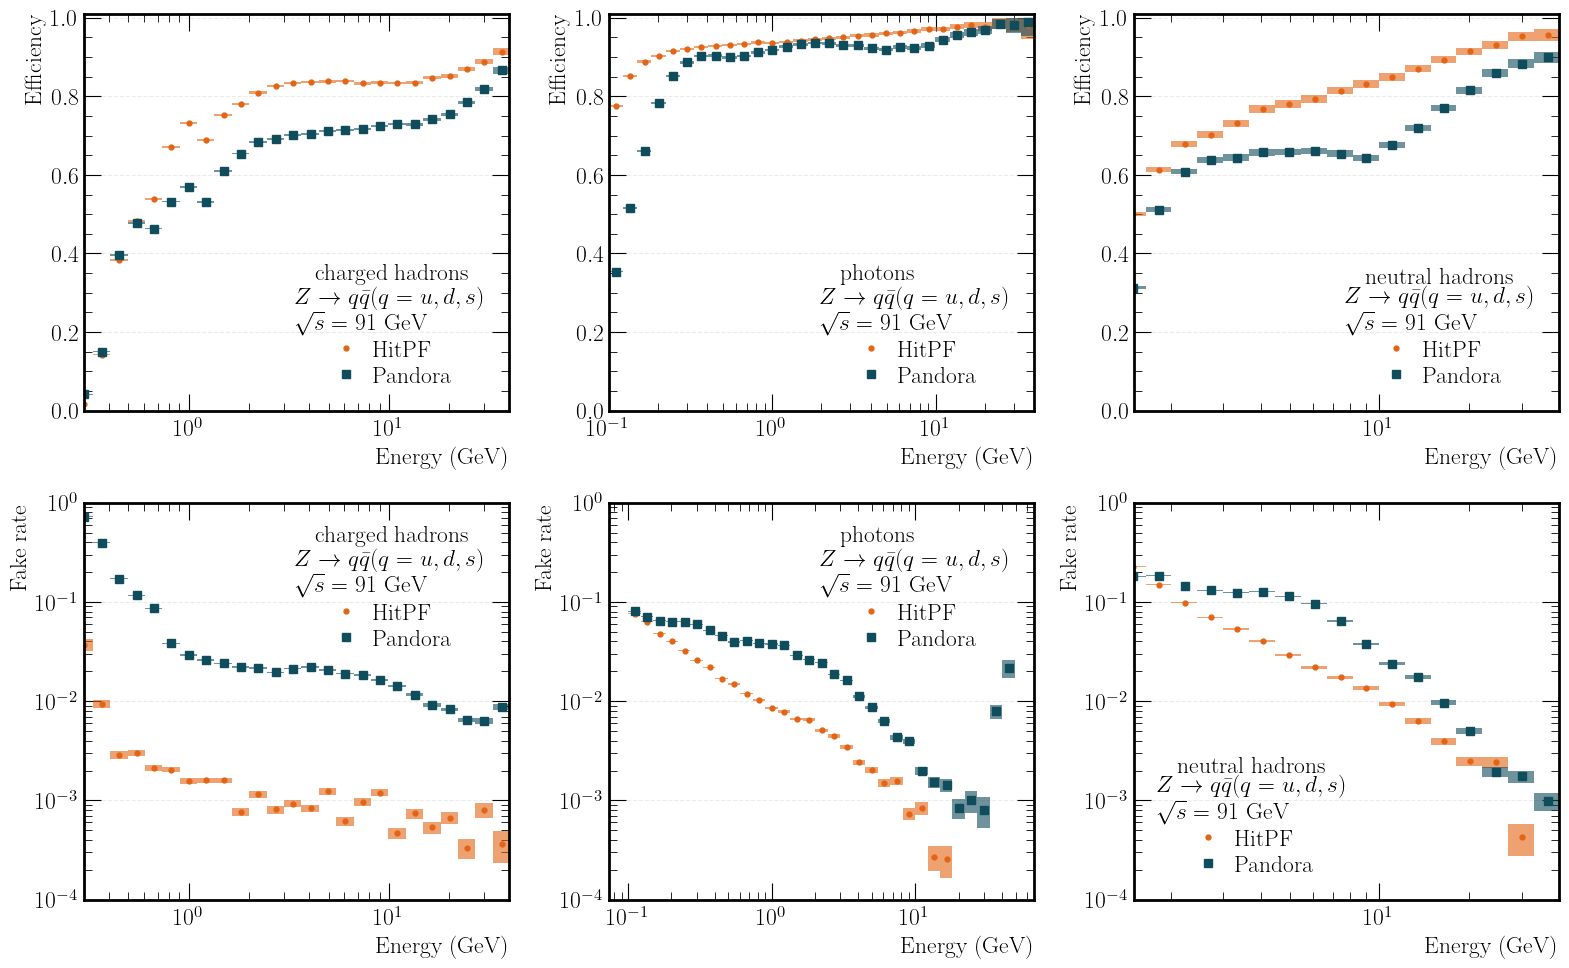

In [14]:
################################### Efficiency plot #####################################################################################################################################################################
######################################################################################################################################################################################################
fig_eff, ax_eff = plt.subplots(2, 3, figsize=(16, 10))
import matplotlib
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
size_font = 17
colors_list = ["#0F4C5C", "#E36414", "#E36414"]
STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=7) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='s', linestyle='None', markersize=6)
ls =0.2
htp = 0.4
################################### Efficiency plot  FOR THE APPENDIX WITH PID AND FAKE ENERGY#####################################################################################################################################################################
######################################################################################################################################################################################################
ax_eff[0,1].plot(eff_dic["photons"]["energy_eff_" + str(0)][:-1],
            eff_dic["photons"]["eff_pid" + "_" + str(0)][:-1],label="HitPF", **STYLE_OURS)
ax_eff[0,1].plot(eff_dic["photons"]["energy_eff_p"][:-1],
            eff_dic["photons"]["eff_p_pid"][:-1], label="Pandora", **STYLE_PANDORA)
ax_eff[0,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,1].set_ylabel("Efficiency",fontsize=size_font)
ax_eff[0,1].set_ylim([0,1.01])
ax_eff[0,1].legend(fontsize = size_font, title_fontsize=size_font, title=r"photons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
ax_eff[0,1].set_xlim([1e-1,40])
plot_error_bars(eff_dic["photons"],ax_eff[0,1], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2)))
plot_error_bars_pandora(eff_dic["photons"],ax_eff[0,1], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2)))


bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.7))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_widths = np.diff(bins)
y = eff_dic["photons"]["eff_0"]
#################################
ax_eff[0,0].plot(eff_dic["pions"]["energy_eff_" + str(0)][:-1],
            eff_dic["pions"]["eff_pid" + "_" + str(0)][:-1],label="HitPF", **STYLE_OURS)
ax_eff[0,0].plot(eff_dic["pions"]["energy_eff_p"][:-1],
            eff_dic["pions"]["eff_p_pid"][:-1], label="Pandora", **STYLE_PANDORA)
plot_error_bars(eff_dic["pions"],ax_eff[0,0], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[1:])
plot_error_bars_pandora(eff_dic["pions"],ax_eff[0,0], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[1:])
# ax_eff[0,1].set_title("Charged Hadrons",fontsize=size_font)
ax_eff[0,0].legend(fontsize = size_font, title_fontsize=size_font, title=r"charged hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
ax_eff[0,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,0].set_ylabel("Efficiency",fontsize=size_font)
ax_eff[0,0].set_ylim([0,1.01])
ax_eff[0,0].set_xlim([0.3,40])
#################################


ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_" + str(0)],
            eff_dic["kaons"]["eff_pid" + "_" + str(0)],label="HitPF", **STYLE_OURS)
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_p"],
            eff_dic["kaons"]["eff_p_pid"], label="Pandora", **STYLE_PANDORA)
ax_eff[0,2].legend(fontsize = size_font,  title_fontsize=size_font,title=r"neutral hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)

plot_error_bars(eff_dic["kaons"],ax_eff[0,2], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[8:])
plot_error_bars_pandora(eff_dic["kaons"],ax_eff[0,2], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[8:])
ax_eff[0,2].set_xlabel("Energy (GeV)",fontsize=size_font)
# ax_eff[0,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[0,2].set_ylabel("Efficiency",fontsize=size_font)
ax_eff[0,2].set_ylim([0,1.01])
ax_eff[0,2].set_xlim([1.5,40])
##Fake rate #################################
ax_eff[1,1].plot(eff_dic["photons"]["energy_fakes_" + str(0)],
            eff_dic["photons"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,1].plot(eff_dic["photons"]["energy_fakes_p"],
        eff_dic["photons"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,1].set_ylabel("Fake rate",fontsize=size_font)
# ax_eff[1,1].set_title(r"$\gamma$",fontsize=size_font)
ax_eff[1,1].set_ylim([1e-4,1])
ax_eff[1,1].legend(fontsize = size_font,  title_fontsize=size_font,title=r"photons\\ $Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
pot_error_bar_fakes(eff_dic["photons"], ax_eff[1,1], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2)))
pot_error_bar_fakes_pandora(eff_dic["photons"], ax_eff[1,1], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2)))
ax_eff[1,1].set_yscale("log")
#################################
ax_eff[1,0].plot(eff_dic["pions"]["energy_fakes_" + str(0)],
    eff_dic["pions"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,0].plot(eff_dic["pions"]["energy_fakes_p"],
        eff_dic["pions"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,0].set_ylabel("Fake rate",fontsize=size_font)
# ax_eff[1,0].set_title("Chardged Hadrons",fontsize=size_font)
ax_eff[1,0].legend(fontsize = size_font,  title_fontsize=size_font,title=r"charged hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
pot_error_bar_fakes(eff_dic["pions"], ax_eff[1,0], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[1:])
pot_error_bar_fakes_pandora(eff_dic["pions"], ax_eff[1,0], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[1:])
ax_eff[1,0].set_ylim([1e-4,1])
ax_eff[1,0].set_xlim([0.3,40])
ax_eff[1,0].set_yscale("log")
ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_" + str(0)],
    eff_dic["kaons"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_p"],
        eff_dic["kaons"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,2].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,2].set_ylabel("Fake rate",fontsize=size_font)
# ax_eff[1,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[1,2].legend(fontsize = size_font, title_fontsize=size_font, title=r"neutral hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower left",labelspacing=ls,handletextpad=htp)
pot_error_bar_fakes(eff_dic["kaons"], ax_eff[1,2], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2)))
pot_error_bar_fakes_pandora(eff_dic["kaons"], ax_eff[1,2], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[4:])
ax_eff[1,2].set_ylim([1e-4,1])
ax_eff[1,2].set_xlim([1.5,40])
ax_eff[1,2].set_yscale("log")
legend_elements = [
    Line2D([0], [0], **STYLE_OURS, label="HitPF"),
    Line2D([0], [0], **STYLE_PANDORA, label="PandoraPFA"),
]


for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)

plt.rcParams['font.size'] = size_font
plt.rcParams['font.family'] = "serif"
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
fig_eff.tight_layout()
fig_eff.savefig(os.path.join(PATH_store_summary_plots, "overview_Efficiency_FakeRate_more_bins.pdf"))

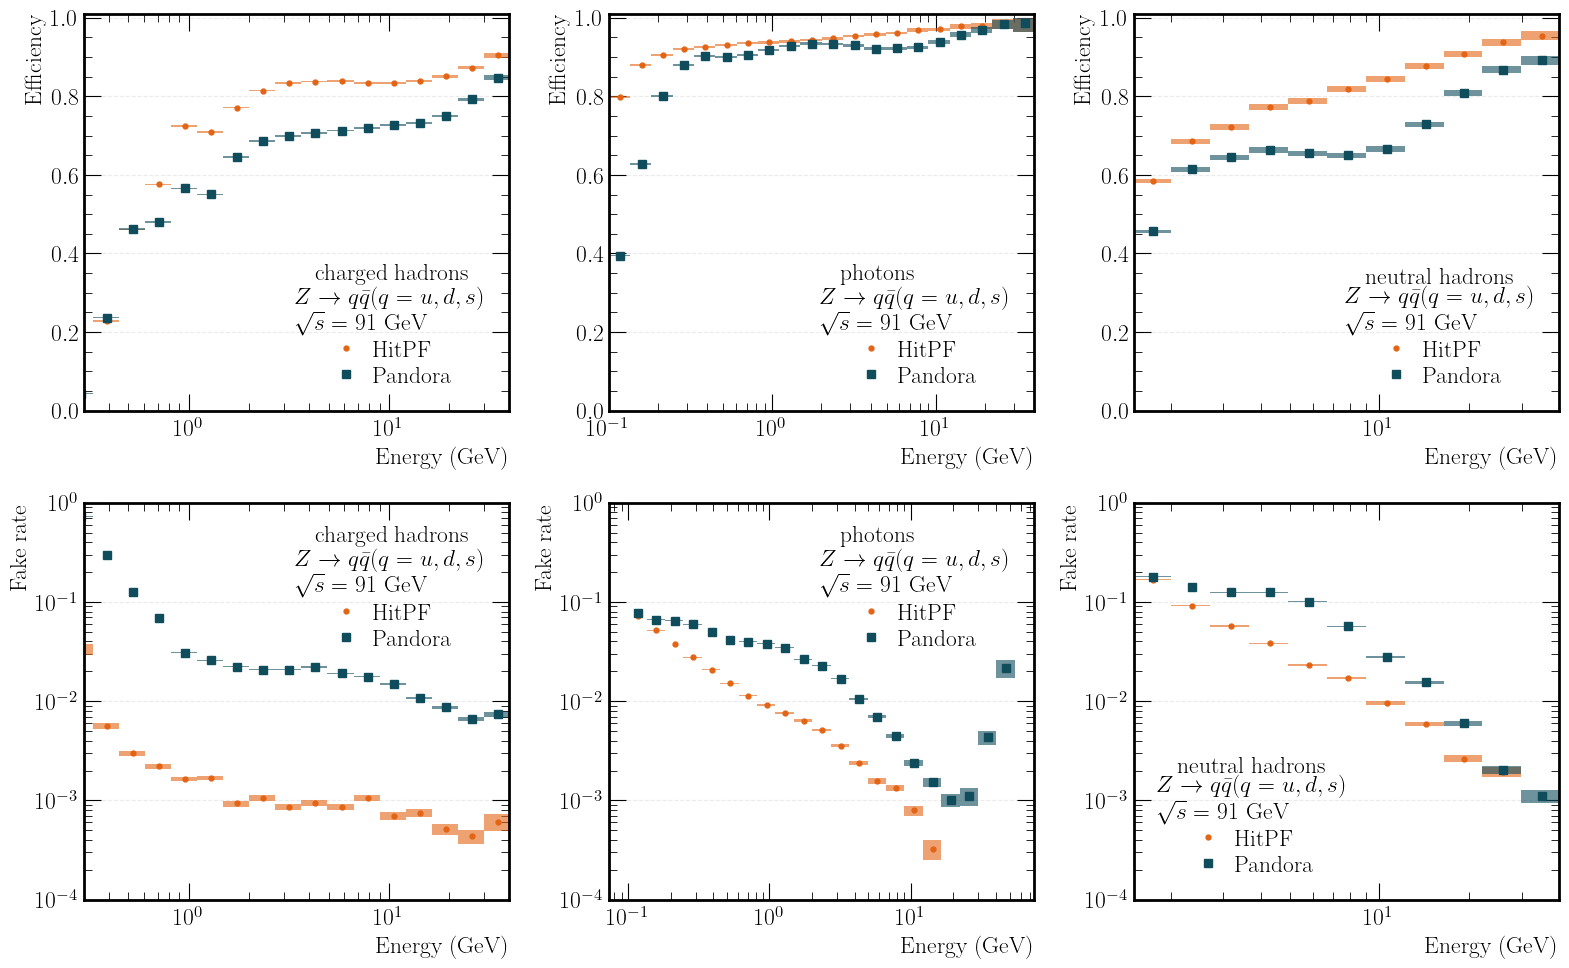

In [33]:
################################### Efficiency plot #####################################################################################################################################################################
######################################################################################################################################################################################################
fig_eff, ax_eff = plt.subplots(2, 3, figsize=(16, 10))
import matplotlib
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
size_font = 17
colors_list = ["#0F4C5C", "#E36414", "#E36414"]
STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=7) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='s', linestyle='None', markersize=6)
ls =0.2
htp = 0.4
################################### Efficiency plot  FOR THE APPENDIX WITH PID AND FAKE ENERGY#####################################################################################################################################################################
######################################################################################################################################################################################################
ax_eff[0,1].plot(eff_dic["photons"]["energy_eff_" + str(0)][:-1],
            eff_dic["photons"]["eff_pid" + "_" + str(0)][:-1],label="HitPF", **STYLE_OURS)
ax_eff[0,1].plot(eff_dic["photons"]["energy_eff_p"][:-1],
            eff_dic["photons"]["eff_p_pid"][:-1], label="Pandora", **STYLE_PANDORA)
ax_eff[0,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,1].set_ylabel("Efficiency",fontsize=size_font)
ax_eff[0,1].set_ylim([0,1.01])
ax_eff[0,1].legend(fontsize = size_font, title_fontsize=size_font, title=r"photons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
ax_eff[0,1].set_xlim([1e-1,40])
plot_error_bars(eff_dic["photons"],ax_eff[0,1], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
plot_error_bars_pandora(eff_dic["photons"],ax_eff[0,1], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))


bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.7))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_widths = np.diff(bins)
y = eff_dic["photons"]["eff_0"]
#################################
ax_eff[0,0].plot(eff_dic["pions"]["energy_eff_" + str(0)][:-1],
            eff_dic["pions"]["eff_pid" + "_" + str(0)][:-1],label="HitPF", **STYLE_OURS)
ax_eff[0,0].plot(eff_dic["pions"]["energy_eff_p"][:-1],
            eff_dic["pions"]["eff_p_pid"][:-1], label="Pandora", **STYLE_PANDORA)
plot_error_bars(eff_dic["pions"],ax_eff[0,0], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[1:])
plot_error_bars_pandora(eff_dic["pions"],ax_eff[0,0], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[1:])
# ax_eff[0,1].set_title("Charged Hadrons",fontsize=size_font)
ax_eff[0,0].legend(fontsize = size_font, title_fontsize=size_font, title=r"charged hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
ax_eff[0,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,0].set_ylabel("Efficiency",fontsize=size_font)
ax_eff[0,0].set_ylim([0,1.01])
ax_eff[0,0].set_xlim([0.3,40])
#################################


ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_" + str(0)],
            eff_dic["kaons"]["eff_pid" + "_" + str(0)],label="HitPF", **STYLE_OURS)
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_p"],
            eff_dic["kaons"]["eff_p_pid"], label="Pandora", **STYLE_PANDORA)
ax_eff[0,2].legend(fontsize = size_font,  title_fontsize=size_font,title=r"neutral hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)

plot_error_bars(eff_dic["kaons"],ax_eff[0,2], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[5:])
plot_error_bars_pandora(eff_dic["kaons"],ax_eff[0,2], "_pid", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[5:])
ax_eff[0,2].set_xlabel("Energy (GeV)",fontsize=size_font)
# ax_eff[0,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[0,2].set_ylabel("Efficiency",fontsize=size_font)
ax_eff[0,2].set_ylim([0,1.01])
ax_eff[0,2].set_xlim([1.5,40])
##Fake rate #################################
ax_eff[1,1].plot(eff_dic["photons"]["energy_fakes_" + str(0)],
            eff_dic["photons"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,1].plot(eff_dic["photons"]["energy_fakes_p"],
        eff_dic["photons"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,1].set_ylabel("Fake rate",fontsize=size_font)
# ax_eff[1,1].set_title(r"$\gamma$",fontsize=size_font)
ax_eff[1,1].set_ylim([1e-4,1])
ax_eff[1,1].legend(fontsize = size_font,  title_fontsize=size_font,title=r"photons\\ $Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
pot_error_bar_fakes(eff_dic["photons"], ax_eff[1,1], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
pot_error_bar_fakes_pandora(eff_dic["photons"], ax_eff[1,1], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
ax_eff[1,1].set_yscale("log")
#################################
ax_eff[1,0].plot(eff_dic["pions"]["energy_fakes_" + str(0)],
    eff_dic["pions"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,0].plot(eff_dic["pions"]["energy_fakes_p"],
        eff_dic["pions"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,0].set_ylabel("Fake rate",fontsize=size_font)
# ax_eff[1,0].set_title("Chardged Hadrons",fontsize=size_font)
ax_eff[1,0].legend(fontsize = size_font,  title_fontsize=size_font,title=r"charged hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
pot_error_bar_fakes(eff_dic["pions"], ax_eff[1,0], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[1:])
pot_error_bar_fakes_pandora(eff_dic["pions"], ax_eff[1,0], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[1:])
ax_eff[1,0].set_ylim([1e-4,1])
ax_eff[1,0].set_xlim([0.3,40])
ax_eff[1,0].set_yscale("log")
ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_" + str(0)],
    eff_dic["kaons"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_p"],
        eff_dic["kaons"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,2].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,2].set_ylabel("Fake rate",fontsize=size_font)
# ax_eff[1,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[1,2].legend(fontsize = size_font, title_fontsize=size_font, title=r"neutral hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower left",labelspacing=ls,handletextpad=htp)
pot_error_bar_fakes(eff_dic["kaons"], ax_eff[1,2], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
pot_error_bar_fakes_pandora(eff_dic["kaons"], ax_eff[1,2], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[3:])
ax_eff[1,2].set_ylim([1e-4,1])
ax_eff[1,2].set_xlim([1.5,40])
ax_eff[1,2].set_yscale("log")
legend_elements = [
    Line2D([0], [0], **STYLE_OURS, label="HitPF"),
    Line2D([0], [0], **STYLE_PANDORA, label="PandoraPFA"),
]


for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)

plt.rcParams['font.size'] = size_font
plt.rcParams['font.family'] = "serif"
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
fig_eff.tight_layout()
fig_eff.savefig(os.path.join(PATH_store_summary_plots, "overview_Efficiency_FakeRate_v1_allEcor_v2_new_data_size_17_gene.pdf"))

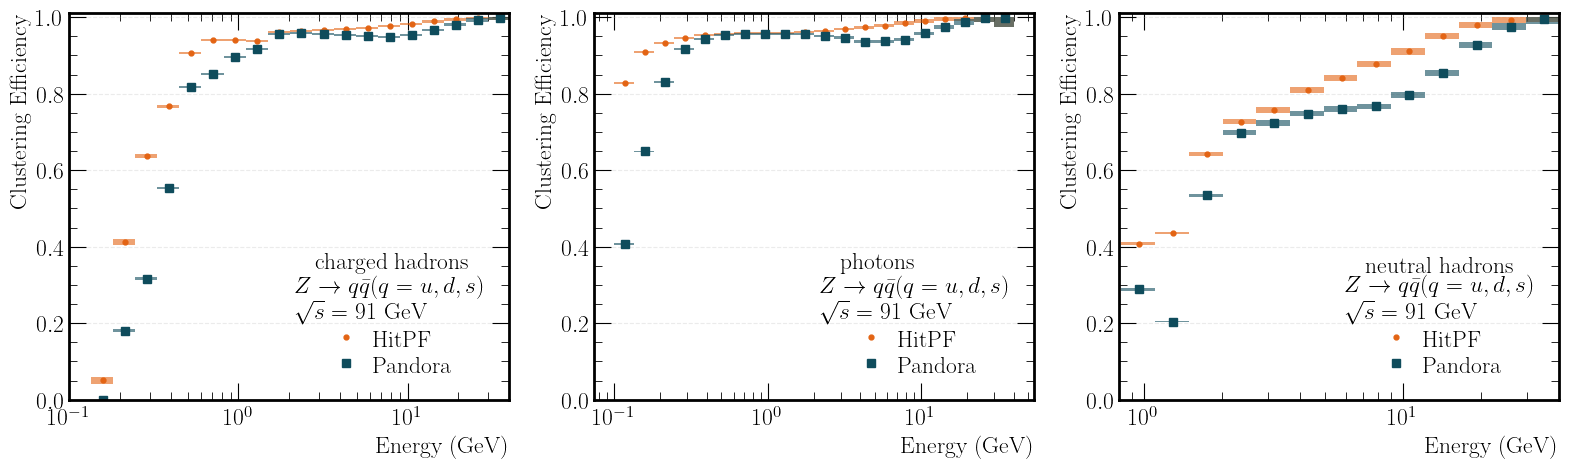

In [27]:
################################### Efficiency plot #####################################################################################################################################################################
######################################################################################################################################################################################################
fig_eff, ax_eff = plt.subplots(1, 3, figsize=(16, 5))
import matplotlib
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
size_font = 17
colors_list = ["#0F4C5C", "#E36414", "#E36414"]
STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=7) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='s', linestyle='None', markersize=6)
ax_eff[1].plot(eff_dic["photons"]["energy_eff_" + str(0)][:-1],
            eff_dic["photons"]["eff" + "_" + str(0)][:-1], **STYLE_OURS, label="HitPF",)
ax_eff[1].plot(eff_dic["photons"]["energy_eff_p"][:-1],
            eff_dic["photons"]["eff_p"][:-1], **STYLE_PANDORA, label="Pandora",)
ax_eff[1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1].set_ylabel("Clustering Efficiency",fontsize=size_font)
plot_error_bars(eff_dic["photons"],ax_eff[1], "", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
plot_error_bars_pandora(eff_dic["photons"],ax_eff[1], "", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
ax_eff[1].set_ylim([0,1.01])

ls =0.2
htp = 0.4
ax_eff[1].legend(fontsize = size_font, title_fontsize=size_font, title=r"photons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
y = eff_dic["photons"]["eff_0"]
#################################
ax_eff[0].plot(eff_dic["pions"]["energy_eff_" + str(0)][:-1],
            eff_dic["pions"]["eff" + "_" + str(0)][:-1],  label="HitPF", **STYLE_OURS)
ax_eff[0].plot(eff_dic["pions"]["energy_eff_p"][:-1],
            eff_dic["pions"]["eff_p"][:-1], label="Pandora", **STYLE_PANDORA)
plot_error_bars(eff_dic["pions"],ax_eff[0], "", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[1:])
# ax_eff[0,0].set_title("Charged Hadrons",fontsize=size_font)
ax_eff[0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0].set_ylabel("Clustering Efficiency",fontsize=size_font)
ax_eff[0].set_ylim([0,1.01])
ax_eff[0].set_xlim([1e-1,40])
ax_eff[0].legend(fontsize = size_font, title_fontsize=size_font, title=r"charged hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
plot_error_bars_pandora(eff_dic["pions"],ax_eff[0], "", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[1:])
#################################
ax_eff[2].plot(eff_dic["kaons"]["energy_eff_" + str(0)][:-1],
            eff_dic["kaons"]["eff" + "_" + str(0)][:-1], label="HitPF", **STYLE_OURS)
ax_eff[2].plot(eff_dic["kaons"]["energy_eff_p"][:-1],
            eff_dic["kaons"]["eff_p"][:-1], label="Pandora", **STYLE_PANDORA)
plot_error_bars(eff_dic["kaons"],ax_eff[2], "", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[5:])
plot_error_bars_pandora(eff_dic["kaons"],ax_eff[2], "", bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[5:])
ax_eff[2].set_xlabel("Energy (GeV)",fontsize=size_font)
# ax_eff[0,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[2].set_ylabel("Clustering Efficiency",fontsize=size_font)
ax_eff[2].set_ylim([0,1.01])
ax_eff[2].set_xlim([0.8,40])
ax_eff[2].legend(fontsize = size_font,  title_fontsize=size_font,title=r"neutral hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
##Fake rate #################################
# ax_eff[1,1].plot(eff_dic["photons"]["energy_fakes_" + str(0)],
#             eff_dic["photons"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
# ax_eff[1,1].plot(eff_dic["photons"]["energy_fakes_p"],
#         eff_dic["photons"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
# ax_eff[1,1].set_xlabel("Energy (GeV)",fontsize=size_font)
# ax_eff[1,1].set_ylabel("Fake rate",fontsize=size_font)
# # ax_eff[1,1].set_title(r"$\gamma$",fontsize=size_font)
# ax_eff[1,1].set_ylim([1e-4,1])
# ax_eff[1,1].legend(fontsize = size_font,  title_fontsize=size_font,title=r"photons\\ $Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
# pot_error_bar_fakes(eff_dic["photons"], ax_eff[1,1], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
# pot_error_bar_fakes_pandora(eff_dic["photons"], ax_eff[1,1], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
# ax_eff[1,1].set_yscale("log")
# #################################
# ax_eff[1,0].plot(eff_dic["pions"]["energy_fakes_" + str(0)],
#     eff_dic["pions"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
# ax_eff[1,0].plot(eff_dic["pions"]["energy_fakes_p"],
#         eff_dic["pions"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
# ax_eff[1,0].set_xlabel("Energy (GeV)",fontsize=size_font)
# ax_eff[1,0].set_ylabel("Fake rate",fontsize=size_font)
# # ax_eff[1,0].set_title("Chardged Hadrons",fontsize=size_font)
# ax_eff[1,0].legend(fontsize = size_font,  title_fontsize=size_font,title=r"charged hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
# pot_error_bar_fakes(eff_dic["pions"], ax_eff[1,0], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[2:])
# pot_error_bar_fakes_pandora(eff_dic["pions"], ax_eff[1,0], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[1:])
# ax_eff[1,0].set_ylim([1e-4,1])
# ax_eff[1,0].set_xlim([1e-1,40])
# ax_eff[1,0].set_yscale("log")
# ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_" + str(0)],
#     eff_dic["kaons"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
# ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_p"],
#         eff_dic["kaons"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
# ax_eff[1,2].set_xlabel("Energy (GeV)",fontsize=size_font)
# ax_eff[1,2].set_ylabel("Fake rate",fontsize=size_font)
# # ax_eff[1,2].set_title("Neutral Hadrons",fontsize=size_font)
# ax_eff[1,2].legend(fontsize = size_font, title_fontsize=size_font, title=r"neutral hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower left",labelspacing=ls,handletextpad=htp)
# pot_error_bar_fakes(eff_dic["kaons"], ax_eff[1,2], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
# pot_error_bar_fakes_pandora(eff_dic["kaons"], ax_eff[1,2], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[3:])
# ax_eff[1,2].set_ylim([1e-4,1])
# ax_eff[1,2].set_xlim([0.8,40])
# ax_eff[1,2].set_yscale("log")
legend_elements = [
    Line2D([0], [0], **STYLE_OURS, label="HitPF"),
    Line2D([0], [0], **STYLE_PANDORA, label="PandoraPFA"),
]


for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)

plt.rcParams['font.size'] = size_font
plt.rcParams['font.family'] = "serif"
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
fig_eff.tight_layout()
fig_eff.savefig(os.path.join(PATH_store_summary_plots, "overview_Efficiency_clustering.pdf"))

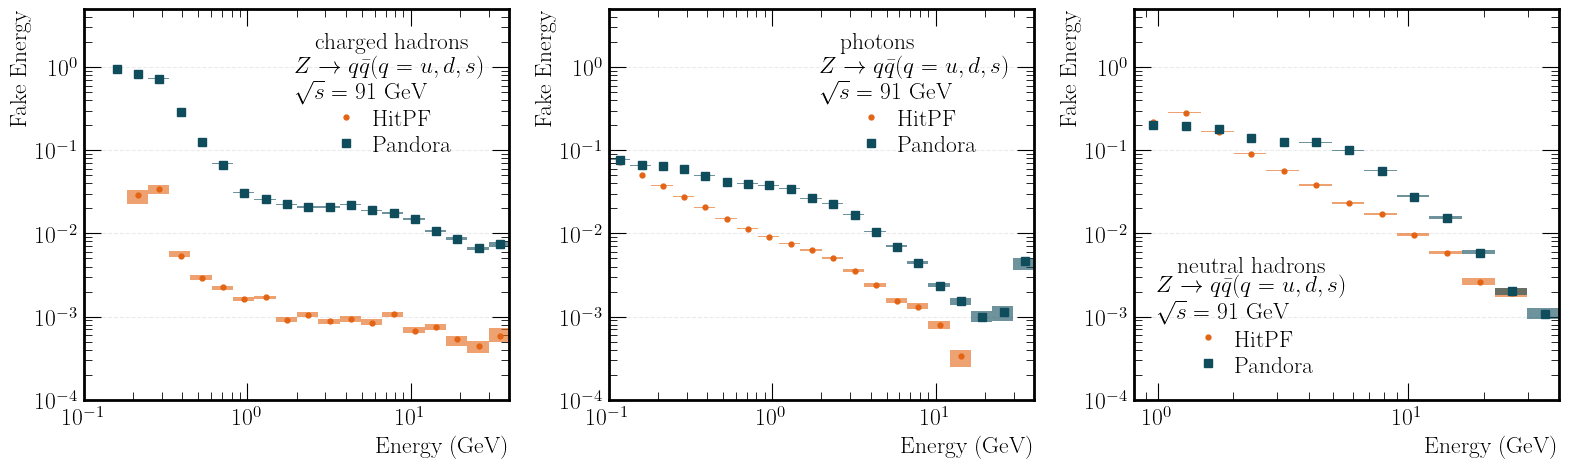

In [18]:
################################### Efficiency plot  FOR THE APPENDIX WITH PID AND FAKE ENERGY#####################################################################################################################################################################
######################################################################################################################################################################################################
fig_eff, ax_eff = plt.subplots(1, 3, figsize=(16, 5))
import matplotlib
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
size_font = 17
colors_list = ["#0F4C5C", "#E36414", "#E36414"]
STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=7) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='s', linestyle='None', markersize=6)
ls =0.2
htp = 0.4
bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.7))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_widths = np.diff(bins)
y = eff_dic["photons"]["eff_0"]
#################################

##Fake rate #################################
ax_eff[1].plot(eff_dic["photons"]["energy_fakes_" + str(0)],
            eff_dic["photons"]["fake_percent_energy_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1].plot(eff_dic["photons"]["energy_fakes_p"],
        eff_dic["photons"]["fake_percent_energy_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1].set_ylabel("Fake Energy %",fontsize=size_font)
# ax_eff[1,1].set_title(r"$\gamma$",fontsize=size_font)
ax_eff[1].legend(fontsize = size_font, title_fontsize=size_font,title=r"photons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
ax_eff[1].set_ylim([1e-4,5])
ax_eff[1].set_xlim([1e-1,40])
ax_eff[1].set_yscale("log")
pot_error_bar_fakes_energy(eff_dic["photons"], ax_eff[1], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
pot_error_bar_fakes_energy_pandora(eff_dic["photons"], ax_eff[1], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
#################################
ax_eff[0].plot(eff_dic["pions"]["energy_fakes_" + str(0)],
    eff_dic["pions"]["fake_percent_energy_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[0].plot(eff_dic["pions"]["energy_fakes_p"],
        eff_dic["pions"]["fake_percent_energy_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0].set_ylabel("Fake Energy %",fontsize=size_font)
# ax_eff[1,0].set_title("Chardged Hadrons",fontsize=size_font)
ax_eff[0].legend(fontsize = size_font,  title_fontsize=size_font, title=r"charged hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
ax_eff[0].set_ylim([1e-4,5])
ax_eff[0].set_xlim([1e-1,40])
ax_eff[0].set_yscale("log")
pot_error_bar_fakes_energy(eff_dic["pions"], ax_eff[0], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[1:])
pot_error_bar_fakes_energy_pandora(eff_dic["pions"], ax_eff[0], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[1:])
ax_eff[2].plot(eff_dic["kaons"]["energy_fakes_" + str(0)],
    eff_dic["kaons"]["fake_percent_energy_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[2].plot(eff_dic["kaons"]["energy_fakes_p"],
        eff_dic["kaons"]["fake_percent_energy_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[2].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[2].set_ylabel("Fake Energy %",fontsize=size_font)
# ax_eff[1,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[2].legend(fontsize = size_font,  title_fontsize=size_font,title=r"neutral hadrons\\$Z\rightarrow q \bar q (q=u,d,s)$\\ $\sqrt s=$ 91 GeV", loc="lower left",labelspacing=ls,handletextpad=htp)
ax_eff[2].set_ylim([1e-4,5])
ax_eff[2].set_xlim([0.8,40])
ax_eff[2].set_yscale("log")
pot_error_bar_fakes_energy(eff_dic["kaons"], ax_eff[2], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
pot_error_bar_fakes_energy_pandora(eff_dic["kaons"], ax_eff[2], i=0, bins=np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[3:])
legend_elements = [
    Line2D([0], [0], **STYLE_OURS, label="HitPF"),
    Line2D([0], [0], **STYLE_PANDORA, label="PandoraPFA"),
]


for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
plt.rcParams['font.size'] = size_font
plt.rcParams['font.family'] = "serif"
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
fig_eff.tight_layout()
fig_eff.savefig(os.path.join(PATH_store_summary_plots, "FakeEnergy.pdf"))

In [16]:
# from src.utils.inference.event_metrics import get_response_for_event_energy
from src.utils.inference.event_metrics import calculate_event_energy_resolution, calculate_event_mass_resolution
from src.utils.inference.inference_metrics import get_sigma_gaussian
def get_response_for_event_energy(matched_pandora, matched_, perfect_pid=False, mass_zero=False, ML_pid=False, pandora=False):
    if pandora:
        (
            mean_p,
            variance_om_p,
            distr_p,
            x_p,
            _,
            _,
            _,
            mass_over_true_pandora,
        ) = calculate_event_energy_resolution(matched_pandora, True, False)
    (
        mean,
        variance_om,
        distr,
        x,
        mean_baseline,
        variance_om_baseline,
        _,
        mass_over_true_model,
    ) = calculate_event_energy_resolution(matched_, False, False)
    if pandora:
        dic_pandora = calculate_event_mass_resolution(matched_pandora, True, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, fake=False)
    
    dic_model = calculate_event_mass_resolution(matched_, False, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, fake=False)
    # mean_mass_perfect_PID, var_mass_perfect_PID, distr_mass_perfect_PID, mass_true_perfect_PID, _, _, E_over_true_perfect_PID, E_over_true_reco_perfect_PID = calculate_event_mass_resolution(matched_, False, perfect_pid=True, mass_zero=False, ML_pid=False,  fake=True)
    # matched_.calibrated_E = matched_.pred_showers_E
    df_copy = matched_.copy(deep=True)
    df_copy.true_showers_E = matched_.reco_showers_E
    # matched_pandora.pandora_calibrated_pfo = matched_pandora.pred_showers_E
    # matched_.pred_pos_matched = matched_.true_pos
    dic_perfect_E = calculate_event_mass_resolution(df_copy, False, perfect_pid=False, mass_zero=False, ML_pid=True, fake=False)
    if pandora:
        dic_perfect_E_pandora = calculate_event_mass_resolution(matched_pandora, True, perfect_pid=False, mass_zero=False, ML_pid=True, fake=False)
    (
        mean_energy_over_true,
        var_energy_over_true,
        _,
        _,
    ) = get_sigma_gaussian(dic_model["E_over_true"], np.linspace(0, 2, 400), epsilon=0.005)
    mean_predtotrue = np.median(dic_model["E_over_true"])
    p16 = np.percentile(dic_model["E_over_true"], 16)
    p84 = np.percentile(dic_model["E_over_true"], 84)
    var_predtotrue = p84 - p16

    mean_mass= np.median(dic_model["mass_over_true_p"] )
    p16 = np.percentile(dic_model["mass_over_true_p"] , 16)
    p84 = np.percentile(dic_model["mass_over_true_p"] , 84)
    var_mass= p84 - p16
    if pandora:
        (
            mean_energy_over_true_pandora,
            var_energy_over_true_pandora,
            _,
            _,
        ) = get_sigma_gaussian(dic_pandora["E_over_true"], np.linspace(0, 2, 400), epsilon=0.005)
        mean_predtotruep = np.median(dic_pandora["E_over_true"])
        p16 = np.percentile(dic_pandora["E_over_true"], 16)
        p84 = np.percentile(dic_pandora["E_over_true"], 84)
        var_predtotruep = p84 - p16
        mean_massp= np.median( dic_pandora["mass_over_true_p"]  )
        p16 = np.percentile( dic_pandora["mass_over_true_p"]  , 16)
        p84 = np.percentile( dic_pandora["mass_over_true_p"]  , 84)
        var_massp= p84 - p16
    dic = {}
    if pandora:
        dic["mean_p"] = mean_p
        dic["variance_om_p"] = variance_om_p
        dic["energy_resolutions_p"] = x_p
        dic["distributions_pandora"] = distr_p
        
        dic["mass_over_true_model_perfect_E_pandora"] = dic_perfect_E_pandora["mass_over_true_p"]
        dic["mass_pandora"] = dic_pandora["mass_pred_p"] 
        dic["mass_pandora_mean"] = dic_pandora["mass_pred_p_mean"]
        dic["mass_pandora_var"] = dic_pandora["mass_pred_p_var"]
        dic["mass_model_mean16p"] = mean_massp
        dic["mass_model_var16p"] = var_massp
        dic["mass_true"] =  dic_pandora["mass_true"]
        dic["mass_true_mean"] =  dic_pandora["mass_true_mean"]
        dic["mass_true_var"] =  dic_pandora["mass_true_var"]
        dic["mass_over_true_model_perfect_E"] = dic_perfect_E["mass_over_true_p"]
        dic["mass_over_true_pandora"] = dic_pandora["mass_over_true_p"]
        dic["var_mass_pandora"] = dic_pandora["var_mass"]
        dic["mean_mass_pandora"] = dic_pandora["mean_mass"]
        dic["energy_over_true_pandora"] = dic_pandora["E_over_true"]
        dic["energy_over_true_reco_pandora"] = dic_pandora["E_over_true_reco"]
        dic["var_energy_over_true_pandora"] = var_energy_over_true_pandora
        dic["mean_energy_over_true_pandora"] = mean_energy_over_true_pandora
        dic["var_energy_over_true_pandora16"] = var_predtotruep
        dic["mean_energy_over_true_pandora16"] = mean_predtotruep

    dic["mass_over_true_model"] = dic_model["mass_over_true_p"]
    dic["variance_om"] = variance_om
    dic["mean"] = mean
    dic["energy_resolutions"] = x
    dic["mean_baseline"] = mean_baseline
    dic["variance_om_baseline"] = variance_om_baseline
    dic["distributions_model"] = distr
    dic["mass_model"] = dic_model["mass_pred_p"] 
    dic["mass_model_mean"] = dic_model["mass_pred_p_mean"]
    dic["mass_model_var"] = dic_model["mass_pred_p_var"]
    dic["mass_model_mean16"] = mean_mass
    dic["mass_model_var16"] = var_mass
    dic["mean_mass_model"] = dic_model["mean_mass"]
    dic["var_mass_model"] =  dic_model["var_mass"]
    dic["energy_over_true"] = dic_model["E_over_true"]
    dic["mean_energy_over_true"] = mean_energy_over_true
    dic["var_energy_over_true"] = var_energy_over_true
    dic["mean_energy_over_true16"] = mean_predtotrue
    dic["var_energy_over_true16"] = var_predtotrue
    dic["energy_over_true_reco"] = dic_model["E_over_true_reco"]
    
    return dic

colors = {"ML": "red", "ML GTC": "green"}



PATH_store = PATH_store_summary_plots
label_ML="HitPF"
label_ML_GTC="ML GTC",
color_ML_GTC="green"
filename="mass_resolution_comp_corrected_E_mass.pdf"
perfect_pid = False
mass_zero = False
ML_pid = True
matched_all = {label_ML: sd_hgb, label_ML_GTC: sd_hgb}
matched_pandora = sd_pandora
event_res_dic = {} 
for key in matched_all:
        matched_ = matched_all[key]
        event_res_dic[key] = get_response_for_event_energy(
                matched_pandora, matched_, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, pandora=True
            )




/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/event_metrics.py:165: RuntimeWarning: invalid value encountered in divide
  pred_vect /= np.linalg.norm(pred_vect, axis=1).reshape(-1, 1)
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/event_metrics.py:184: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_E_jet = scatter_sum(torch.tensor(true_e), batch_idx)
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/event_metrics.py:185: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_E_jet_reco = scatter_sum(torch.tensor(reco_true_e), batch_idx)
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/event_metrics.py:186: UserWarning: To copy const

In [17]:
dic=  event_res_dic[label_ML]
print(dic["mass_model_mean"])
print(dic["mass_model_var"])
print(dic["mass_model_mean16"]/2   )
print(dic["mass_model_var16"])
print(dic["mean_mass_model"] )
print(dic["var_mass_model"] )
print("pandora", dic["mass_model_mean16p"] )
print("pandora",dic["mass_model_var16p"])

90.19656897784131
0.03578079803463169
0.49683967794543493
0.07818360297029936
1.0
0.03759398496240596
pandora 1.007595351872167
pandora 0.09285145200386935


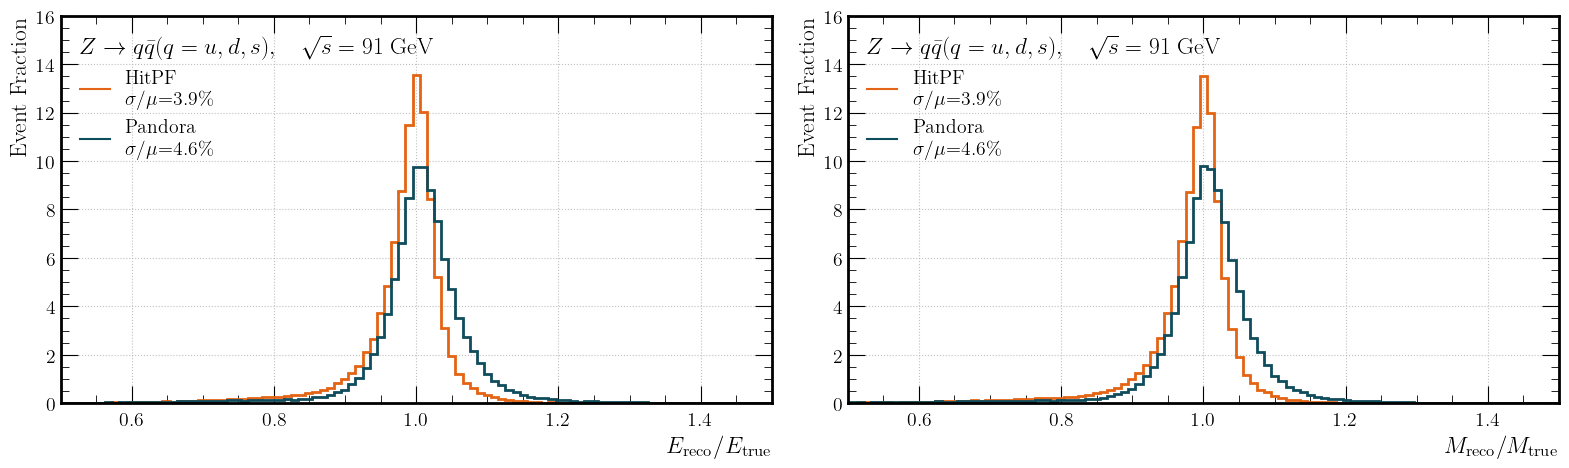

In [7]:
import matplotlib
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
plt.rcParams['text.usetex'] = True
size_font = 17
matplotlib.rcParams.update({'font.size': size_font})
fig, ax = plt.subplots(1, 2,figsize=(16, 5))
ax[1].set_xlabel(r"$M_{\mathrm{reco}}/M_{\mathrm{true}}$")
bins = np.linspace(0, 2, 200)
ax[1].hist(
    event_res_dic[label_ML]["mass_over_true_model"],
    bins=bins,
    histtype="step",
    color= "#E36414", 
    density=True, linewidth=2)
p16p = np.percentile(event_res_dic[label_ML]["energy_over_true_pandora"], 16)
p84p = np.percentile(event_res_dic[label_ML]["energy_over_true_pandora"], 84)
p16 = np.percentile(event_res_dic[label_ML]["energy_over_true"], 16)
p84 = np.percentile(event_res_dic[label_ML]["energy_over_true"], 84)

std_pandora = (p84p-p16p)/(2*np.median(event_res_dic[label_ML]["energy_over_true_pandora"]))
std_model = (p84-p16)/(2*np.median(event_res_dic[label_ML]["energy_over_true"]))
# ax[0].axvline(x=p16p, color='b', linestyle='-',)
# ax[0].axvline(x=p84p, color='b', linestyle='-',)
# ax[0].axvline(x=p16, color='orange', linestyle='-',)
# ax[0].axvline(x=p84, color='orange', linestyle='-',)
ax[1].hist(
    event_res_dic[label_ML]["mass_over_true_pandora"],
    bins=bins,
    histtype="step",
    color="#0F4C5C",
    density=True,
    linewidth=2)

ax[1].grid()


var_m_model_1 = round(std_model*100, 1)
var_m_pandora_1 = round(std_pandora*100, 1)

var_m_model = round((dic["mass_model_var16"]/(2*dic["mass_model_mean16"])*100), 1)
var_m_pandora = round((dic["mass_model_var16p"]/(2*dic["mass_model_mean16p"])*100), 1)

# sigma_e_over_true_pandora = round(event_res_dic[label_ML]["var_energy_over_true_pandora"]/event_res_dic[label_ML]["mean_energy_over_true_pandora"], 3)
# sigma_e_over_true = round(event_res_dic[label_ML]["var_energy_over_true"]/event_res_dic[label_ML]["mean_energy_over_true"], 3)
# mean_e_over_true_gtc, sigma_e_over_true_gtc = round(event_res_dic[label_ML_GTC]["mean_energy_over_true"], 3), round(
#     event_res_dic[label_ML_GTC]["var_energy_over_true"], 3)
ax[0].hist(event_res_dic[label_ML]["energy_over_true"], bins=bins, histtype="step",
            # label=r"ML $\mu$={} $\sigma / \mu$={}".format(mean_e_over_true, sigma_e_over_true),
            color="#E36414",
            density=True, linewidth=2)
   
ax[0].hist(event_res_dic[label_ML]["energy_over_true_pandora"], bins=bins, histtype="step",
                    # label=r"Pandora $\mu$={} $\sigma / \mu$={}".format(mean_e_over_true_pandora,
                    #                                                     sigma_e_over_true_pandora),
                    
                    color="#0F4C5C",
                    density=True, linewidth=2)

ax[0].grid(1)
ax[0].set_xlabel(r"$E_{\mathrm{reco}} / E_{\mathrm{true}}$")
# ax[1].legend(loc='upper left')

# from matplotlib.lines import Line2D
custom_line1 = Line2D([0], [0], color="#E36414",label="HitPF "+"\n"+"$\sigma/\mu$={}$\%$".format(var_m_model_1))
# custom_line_gt = Line2D([0], [0], color="green",label="ML GT "+"\n"+"$\sigma/\mu$={}".format(round((event_res_dic["ML GTC"]["var_mass_model"]), 2),
#     ))

custom_line_pandora = Line2D([0], [0], color="#0F4C5C",label="Pandora "+"\n"+"$\sigma/\mu$={}$\%$".format(var_m_pandora_1),)

custom_line2 = Line2D([0], [0], color="#E36414",label="HitPF "+"\n"+"$\sigma/\mu$={}$\%$".format(var_m_model), )

custom_line_pandora2 = Line2D([0], [0], color="#0F4C5C",label="Pandora "+"\n"+"$\sigma/\mu$={}$\%$".format(var_m_pandora), )


title= r"$Z\rightarrow q\bar q (q=u,d,s), \quad \sqrt{s}=91$ GeV"
leg = ax[0].legend(handles=[custom_line1, custom_line_pandora],loc='upper left',title_fontsize=size_font, title=title)
leg._legend_box.align = "left"
leg1 = ax[1].legend(handles=[custom_line2, custom_line_pandora2],loc='upper left',title_fontsize=size_font,title=title)
leg1._legend_box.align = "left"
ax[0].set_xlim([0.5, 1.5])
ax[1].set_xlim([0.5, 1.5])
ax[0].set_ylim([0, 16])
ax[1].set_ylim([0, 16])
ax[0].set_ylabel("Event Fraction")
ax[1].set_ylabel("Event Fraction")
plt.rc("text", usetex=True)
plt.rc("font", family="serif")

plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font

fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "mass_plot_v2_1684_newdatasize15_v2.pdf"), bbox_inches="tight")


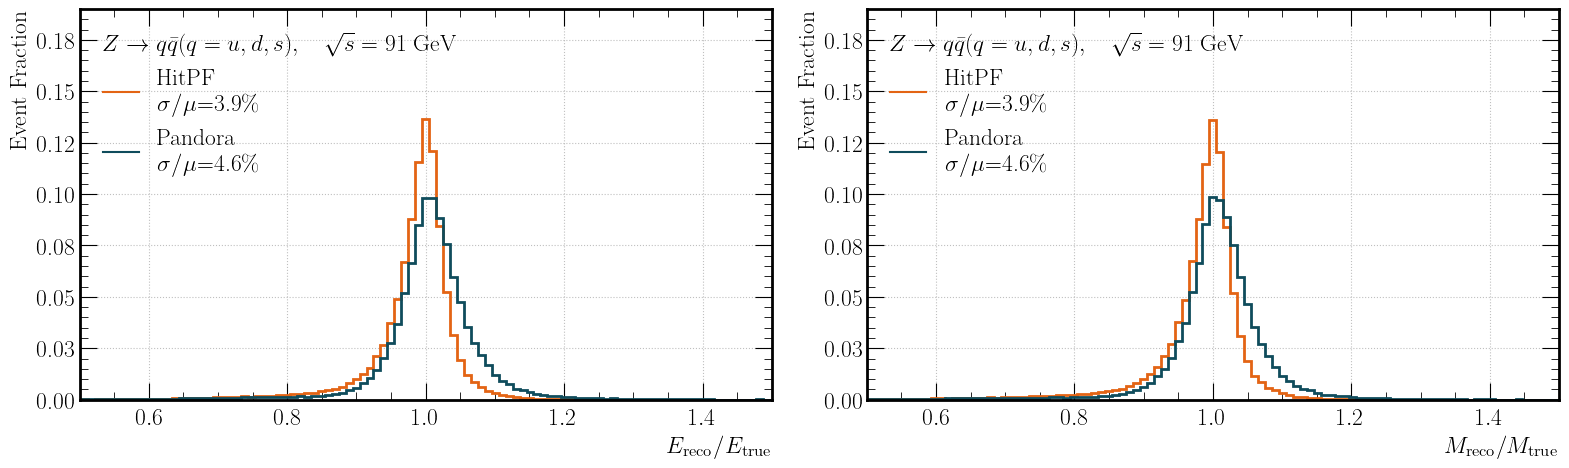

In [24]:
import matplotlib
from matplotlib.ticker import FormatStrFormatter
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
plt.rcParams['text.usetex'] = True
size_font = 17
matplotlib.rcParams.update({'font.size': size_font})
fig, ax = plt.subplots(1, 2,figsize=(16, 5))
ax[1].set_xlabel(r"$M_{\mathrm{reco}}/M_{\mathrm{true}}$")
bins = np.linspace(0, 2, 200)
values = event_res_dic[label_ML]["mass_over_true_model"]
weights = np.ones_like(values) / len(values)

ax[1].hist(
    values,
    bins=bins,
    histtype="step",
    color="#E36414",
    weights=weights,
    linewidth=2
)
p16p = np.percentile(event_res_dic[label_ML]["energy_over_true_pandora"], 16)
p84p = np.percentile(event_res_dic[label_ML]["energy_over_true_pandora"], 84)
p16 = np.percentile(event_res_dic[label_ML]["energy_over_true"], 16)
p84 = np.percentile(event_res_dic[label_ML]["energy_over_true"], 84)

std_pandora = (p84p-p16p)/(2*np.median(event_res_dic[label_ML]["energy_over_true_pandora"]))
std_model = (p84-p16)/(2*np.median(event_res_dic[label_ML]["energy_over_true"]))
# ax[0].axvline(x=p16p, color='b', linestyle='-',)
# ax[0].axvline(x=p84p, color='b', linestyle='-',)
# ax[0].axvline(x=p16, color='orange', linestyle='-',)
# ax[0].axvline(x=p84, color='orange', linestyle='-',)
values = event_res_dic[label_ML]["mass_over_true_pandora"]
weights = np.ones_like(values) / len(values)

ax[1].hist(
    values,
    bins=bins,
    histtype="step",
    color="#0F4C5C",
    weights=weights,
    linewidth=2
)

ax[1].grid()


var_m_model_1 = round(std_model*100, 1)
var_m_pandora_1 = round(std_pandora*100, 1)

var_m_model = round((dic["mass_model_var16"]/(2*dic["mass_model_mean16"])*100), 1)
var_m_pandora = round((dic["mass_model_var16p"]/(2*dic["mass_model_mean16p"])*100), 1)

# sigma_e_over_true_pandora = round(event_res_dic[label_ML]["var_energy_over_true_pandora"]/event_res_dic[label_ML]["mean_energy_over_true_pandora"], 3)
# sigma_e_over_true = round(event_res_dic[label_ML]["var_energy_over_true"]/event_res_dic[label_ML]["mean_energy_over_true"], 3)
# mean_e_over_true_gtc, sigma_e_over_true_gtc = round(event_res_dic[label_ML_GTC]["mean_energy_over_true"], 3), round(
#     event_res_dic[label_ML_GTC]["var_energy_over_true"], 3)
values = event_res_dic[label_ML]["energy_over_true"]
weights = np.ones_like(values) / len(values)

ax[0].hist(
    values,
    bins=bins,
    histtype="step",
    color="#E36414",
    weights=weights,
    linewidth=2
)
   
values = event_res_dic[label_ML]["energy_over_true_pandora"]
weights = np.ones_like(values) / len(values)

ax[0].hist(
    values,
    bins=bins,
    histtype="step",
    color="#0F4C5C",
    weights=weights,
    linewidth=2
)


ax[0].grid(1)
ax[0].set_xlabel(r"$E_{\mathrm{reco}} / E_{\mathrm{true}}$")
# ax[1].legend(loc='upper left')

# from matplotlib.lines import Line2D
custom_line1 = Line2D([0], [0], color="#E36414",label="HitPF "+"\n"+"$\sigma/\mu$={}$\%$".format(var_m_model_1))
# custom_line_gt = Line2D([0], [0], color="green",label="ML GT "+"\n"+"$\sigma/\mu$={}".format(round((event_res_dic["ML GTC"]["var_mass_model"]), 2),
#     ))

custom_line_pandora = Line2D([0], [0], color="#0F4C5C",label="Pandora "+"\n"+"$\sigma/\mu$={}$\%$".format(var_m_pandora_1),)

custom_line2 = Line2D([0], [0], color="#E36414",label="HitPF "+"\n"+"$\sigma/\mu$={}$\%$".format(var_m_model), )

custom_line_pandora2 = Line2D([0], [0], color="#0F4C5C",label="Pandora "+"\n"+"$\sigma/\mu$={}$\%$".format(var_m_pandora), )


title= r"$Z\rightarrow q\bar q (q=u,d,s), \quad \sqrt{s}=91$ GeV"
leg = ax[0].legend(handles=[custom_line1, custom_line_pandora],loc='upper left',title_fontsize=size_font, title=title)
leg._legend_box.align = "left"
leg1 = ax[1].legend(handles=[custom_line2, custom_line_pandora2],loc='upper left',title_fontsize=size_font,title=title)
leg1._legend_box.align = "left"
ax[0].set_xlim([0.5, 1.5])
ax[1].set_xlim([0.5, 1.5])
ax[0].set_ylim([0, 0.19])
ax[1].set_ylim([0, 0.19])
ax[0].set_ylabel("Event Fraction")
ax[1].set_ylabel("Event Fraction")
ax[1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax[0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.rc("text", usetex=True)
plt.rc("font", family="serif")

plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font

fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "mass_plot_v2_1684_newdatasize15_v2.pdf"), bbox_inches="tight")


In [83]:
mean_m_model = round((event_res_dic[label_ML]["mean_mass_model"]), 4)
var_m_model = round((event_res_dic[label_ML]["var_mass_model"]), 4)
mean_m_pandora = round((event_res_dic[label_ML]["mean_mass_pandora"]), 3)
var_m_pandora = round((event_res_dic[label_ML_GTC]["var_mass_pandora"]), 3)
var_m_model, mean_m_model, var_m_model/mean_m_model, var_m_pandora, mean_m_pandora,  var_m_pandora/mean_m_pandora

(0.0399, 1.005, 0.039701492537313435, 0.047, 1.005, 0.04676616915422886)

In [25]:
from src.utils.inference.per_particle_metrics import get_mask_id, particle_masses, particle_masses_4_class, safeint
from src.utils.inference.inference_metrics import get_sigma_gaussian
from src.utils.inference.per_particle_metrics import (
    plot_per_energy_resolution2_multiple, plot_confusion_matrix, plot_confusion_matrix_pandora
    , calc_unit_circle_dist, plot_per_energy_resolution2, analyze_fakes, analyze_fakes_PID,
    plot_cm_per_energy, plot_fake_and_missed_energy_regions, quick_plot_mass,
    plot_cm_per_energy_on_overview, calculate_phi
)

import numpy as np

def delta_theta_batch(reco, true):
    """
    reco: array-like, shape [N, 3]
    true: array-like, shape [N, 3]

    Returns:
        angles: np.ndarray of shape [N]
                delta_theta per event (rad), NaN where invalid.
    """
    reco = np.asarray(reco, dtype=float)
    true = np.asarray(true, dtype=float)

    if reco.shape != true.shape or reco.shape[1] != 3:
        raise ValueError("Inputs must have shape [N, 3]")

    # norms
    reco_norm = np.linalg.norm(reco, axis=1)
    true_norm = np.linalg.norm(true, axis=1)


    # valid mask (finite and non-zero)
    valid = (
        np.isfinite(reco_norm) & (reco_norm > 0) &
        np.isfinite(true_norm) & (true_norm > 0)
    )

    # initialize output
    angles = np.full(reco.shape[0], np.nan)

    if np.any(valid):
        # normalize only valid rows
        u_reco = reco[valid] / reco_norm[valid][:, None]
        u_true = true[valid] / true_norm[valid][:, None]

        # dot products
        c = np.sum(u_reco * u_true, axis=1)
        c = np.clip(c, -1.0, 1.0)
        angles[valid] = np.arccos(c)

    return angles

def calc_phi_angle(df, pandora=False):
    if pandora:
        assert "pandora_calibrated_pos" in df.columns
    pids = []
    distances = []
    true_e = df.true_showers_E.values
    batch_idx = df.number_batch
    if pandora:
        pred_vect = np.array(df.pandora_calibrated_pos.values.tolist())
        true_vect = (
            np.array(df.true_pos.values.tolist())
            * torch.tensor(true_e).unsqueeze(1).repeat(1, 3).numpy()
        )
        pred_vect = torch.tensor(pred_vect)
        true_vect = torch.tensor(true_vect)
       
    else:
        pred_vect = np.array(df.pred_pos_matched.values.tolist())
        true_vect = (
            np.array(df.true_pos.values.tolist())
            * torch.tensor(true_e).unsqueeze(1).repeat(1, 3).numpy()
        )
        pred_vect = torch.tensor(pred_vect)
        true_vect = torch.tensor(true_vect)
       
    
    angles_dist = delta_theta_batch(pred_vect,true_vect )
    return angles_dist


def calculate_response(matched, pandora, log_scale=False, tracks=False, perfect_pid=False, mass_zero=False, ML_pid=False, pid=None, ch=False):

    bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.2))
    mean = []
    variance_om = []
    mean_baseline = []
    variance_om_baseline = []
    mean_true_rec = []
    variance_om_true_rec = []
    mean_errors = []
    variance_om_errors = []
    energy_resolutions = []
    energy_resolutions_reco = []
    distributions = []  # Distributions of E/E_{true} for plotting later
    distributions_reco = []
    mean_pxyz = []
    variance_pxyz = []
    masses = []
    is_track_in_cluster = []
    pxyz_true, pxyz_pred = [], []
    sigma_phi, sigma_theta = [], [] # for the angular resolution vs. energy
    distr_phi, distr_theta = [], []
    mean_cld = []
    variance_om_cld = []
    variance_theta_errors = []
    phi_error  = []
    #binning = 1e-2 * 0.2
    if ch:
        number_bins = 3000 
    else:
        number_bins = 500
    bins_per_binned_E = np.linspace(0, 2, number_bins)

    for i in range(len(bins) - 1):
        bin_i = bins[i]
        bin_i1 = bins[i + 1]
        mask_above = matched["true_showers_E"] <= bin_i1
        mask_below = matched["true_showers_E"] > bin_i
        mask_check = ~pd.isna(matched["pred_showers_E"])
        mask = mask_below * mask_above * mask_check
        true_e = matched.true_showers_E[mask]
        true_rec = matched.reco_showers_E[mask]
        if pandora:
            pred_e = matched.pandora_calibrated_pfo[mask]
            pred_pxyz = np.array(matched.pandora_calibrated_pos[mask].tolist())
        else:
            pred_e = matched.calibrated_E[mask]
            pred_pxyz = np.array(matched.pred_pos_matched[mask].tolist())
        pred_e_nocor = matched.pred_showers_E[mask]
        trk_in_clust = matched.is_track_in_cluster[mask]
        if perfect_pid or mass_zero or ML_pid:
            if len(pred_pxyz):
                pred_pxyz /= np.linalg.norm(pred_pxyz, axis=1).reshape(-1, 1)
            if perfect_pid:
                m = np.array([particle_masses[abs(int(i))] for i in matched.pid[mask]])
            elif ML_pid:
                if pandora:
                    m = np.array([particle_masses[abs(int(i))] for i in matched.pandora_pid[mask]])
                else:
                    m = np.array([particle_masses_4_class.get(safeint(i), 0.0) for i in matched.pred_pid_matched[mask]])
            if mass_zero:
                m = np.array([0 for _ in range(len(matched.pid[mask]))])
            p_squared = (pred_e**2 - m**2).values
            pred_pxyz = np.sqrt(p_squared).reshape(-1, 1) * pred_pxyz
        true_pxyz = np.array(matched.true_pos[mask].tolist())

        if np.sum(mask) > 0:  # if the bin is not empty
            e_over_true = pred_e / true_e
            e_over_reco = pred_e_nocor / true_rec
            e_cld_plot = (pred_e-true_e) / true_e**2
            distributions.append(e_over_true)
            dist, _, phi_dist, eta_dist = calc_unit_circle_dist(matched[mask], pandora=pandora)
            mean_theta = np.median(eta_dist)
            p16 = np.percentile(eta_dist, 16)
            p84 = np.percentile(eta_dist, 84)
            var_theta = (p84 - p16)/2
            sigma_theta.append(var_theta)
            variance_theta_errors.append(var_theta/np.sqrt(2*len(eta_dist)))
            distr_theta.append(eta_dist)
            angles_dist = calc_phi_angle(matched[mask], pandora=pandora)
            distr_phi.append(angles_dist)
            sigma_phi_var = np.percentile(angles_dist, 68)
            sigma_phi.append(sigma_phi_var)
            phi_error.append(sigma_phi_var/np.sqrt(2*len(angles_dist)))
            distributions_reco.append(e_cld_plot)

            mean_predtotrue = np.median(e_over_true)
            
            p16 = np.percentile(e_over_true, 16)
            p84 = np.percentile(e_over_true, 84)
            var_predtotrue = p84 - p16
            print(bin_i,bin_i1, len(e_over_true),var_predtotrue/2)
            mean.append(mean_predtotrue)
            variance_om.append(np.abs(var_predtotrue))
            energy_resolutions.append((bin_i1 + bin_i) / 2)
            mean_cld.append(0)
            variance_om_cld.append(np.abs(0))
            sigma = var_predtotrue/(2*mean_predtotrue)
            variance_om_errors.append(sigma/np.sqrt(2*len(e_over_true)))

    return (
        mean,
        variance_om,
        mean_true_rec,
        variance_om_true_rec,
        energy_resolutions,
        energy_resolutions_reco,
        mean_baseline,
        variance_om_baseline,
        distributions,
        0,
        variance_om_errors,
        0,
        0,
        [0, 0],
        0,
        phi_error,
        sigma_phi,
        sigma_theta,
        variance_theta_errors,
        distr_phi,
        distributions_reco, 
        mean_cld, 
        variance_om_cld
    )
def get_response_for_id_i(id, matched_pandora, matched_, tracks=False, perfect_pid=False, mass_zero=False, ML_pid=False, pandora=False):
    if id ==[211]:
        ch=True
    else:
        ch = False
    if pandora:
        pids_pandora = np.abs(matched_pandora["pid"].values)
        mask_id = get_mask_id(id, pids_pandora)
        df_id_pandora = matched_pandora[mask_id]
    pids = np.abs(matched_["pid"].values)
    mask_id = get_mask_id(id, pids)
    df_id = matched_[mask_id]
    if pandora:
        (
            mean_p,
            variance_om_p,
            mean_true_rec_p,
            variance_om_true_rec_p,
            energy_resolutions_p,
            energy_resolutions_reco_p,
            mean_baseline,
            variance_om_baseline,
            e_over_e_distr_pandora,
            mean_errors_p,
            variance_errors_p,
            mean_pxyz_pandora, variance_om_pxyz_pandora, masses_pandora, pxyz_true_p, phi_error_p, sigma_phi_pandora, sigma_theta_pandora, distr_phi_pandora, distr_theta_pandora, distr_E_reco_pandora, mp_cld, varp_cld
        ) = calculate_response(df_id_pandora, True, False, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, pid=id[0], ch=ch)
        # Pandora: TODO: do some sort of PID for Pandora
    (
        mean,
        variance_om,
        mean_true_rec,
        variance_om_true_rec,
        energy_resolutions,
        energy_resolutions_reco,
        mean_baseline,
        variance_om_baseline,
        e_over_e_distr_model,
        mean_errors,
        variance_errors,
        mean_pxyz, variance_om_pxyz, masses, pxyz_true, phi_error_, sigma_phi, sigma_theta, distr_phi, distr_theta, distr_E_reco, m_cld, var_cld
    ) = calculate_response(df_id, False, False, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, pid=id[0], ch=ch)
    # print("COR:__________________________________")
    # print(variance_om_p)
    # print(variance_om)
    # print("RECO:__________________________________")
    # print(variance_om_true_rec_p)
    # print(variance_om_true_rec)
    dic = {}
    if pandora:
        dic["mean_p"] = mean_p
        dic["variance_om_p"] = variance_om_p
        dic["variance_errors_p"] = np.array(variance_errors_p)
        dic["mean_errors_p"] = np.array(mean_errors_p)
        dic["energy_resolutions_p"] = np.array(energy_resolutions_p)
        dic["mean_p_reco"] = np.array(mean_true_rec_p)
        dic["variance_om_p_reco"] = np.array(variance_om_true_rec_p)
        dic["energy_resolutions_p_reco"] = np.array(energy_resolutions_reco_p)
        dic["distributions_pandora"] = e_over_e_distr_pandora
        dic["distributions_pandora_reco"] = distr_E_reco_pandora
        dic["mp_cld"] = mp_cld
        dic["phi_error_p"] = phi_error_p
        dic["varp_cld"] = varp_cld
        dic["sigma_theta_pandora"] = sigma_theta_pandora
        dic["sigma_phi_pandora"] = sigma_phi_pandora
        dic["sigma_errors_theta_pandora"] = distr_phi_pandora
        dic["distr_angles_pandora"] =distr_theta_pandora


    dic["variance_om"] = variance_om
    dic["mean"] = mean
    dic["mean_errors"] = np.array(mean_errors)
    dic["variance_errors"] = np.array(variance_errors)
    dic["energy_resolutions"] = np.array(energy_resolutions)
    dic["mean_reco"] = mean_true_rec
    dic["variance_om_reco"] = np.array(variance_om_true_rec)
    dic["energy_resolutions_reco"] = np.array(energy_resolutions_reco)
    dic["mean_baseline"] = mean_baseline
    dic["variance_om_baseline"] = np.array(variance_om_baseline)
    dic["distributions_model"] = e_over_e_distr_model
    dic["distributions_model_reco"] = distr_E_reco
    dic["sigma_theta"] = sigma_theta
    dic["distr_angles"] =distr_theta
    dic["sigma_phi"] = sigma_phi
    dic["sigma_errors_theta"] = distr_phi
    dic["m_cld"] = m_cld
    dic["var_cld"] = var_cld
    dic["phi_error"] = phi_error_
    
    return dic

In [26]:
tracks = True
# from src.utils.inference.per_particle_metrics import get_response_for_id_i
perfect_pid = False
mass_zero = False
pandora = True
ML_pid = True
matched_pandora_h = sd_pandora[(np.abs(sd_pandora.pid)==22)]
matched_h = sd_hgb[(np.abs(sd_hgb.pid)==22)]
matched_pandora_hadron= matched_pandora_h[(matched_h.pred_pid_matched==3).values*(matched_pandora_h.pandora_pid==22).values]
matched_hadron = matched_h[(matched_h.pred_pid_matched==3).values*(matched_pandora_h.pandora_pid==22).values]
print("PID:22___________________________________________")
photons_dic = get_response_for_id_i(
    [22], matched_pandora_hadron, matched_hadron, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero,pandora=pandora, 
    ML_pid=ML_pid
)

PID:22___________________________________________
0.10000000000000002 0.12214027581601704 11779 0.42751955270767217
0.12214027581601704 0.1491824697641271 19282 0.3896661126613617
0.1491824697641271 0.18221188003905106 27542 0.35716595172882076
0.18221188003905106 0.22255409284924696 35035 0.3283365774154663
0.22255409284924696 0.2718281828459048 39457 0.3033569419384003
0.2718281828459048 0.3320116922736552 42609 0.28615634083747865
0.3320116922736552 0.40551999668446803 43973 0.2615676128864287
0.40551999668446803 0.49530324243951235 43491 0.23832302093505853
0.49530324243951235 0.6049647464412957 41975 0.2196607863903045
0.6049647464412957 0.7389056098930665 40564 0.20378355026245115
0.7389056098930665 0.902501349943414 39189 0.1875899004936219
0.902501349943414 1.1023176380641628 37519 0.17330585837364187
1.1023176380641628 1.3463738035001724 36490 0.15745643973350515
1.3463738035001724 1.6444646771097096 35166 0.14536014199256891
1.6444646771097096 2.0085536923187726 33636 0.13405

In [101]:
# tracks = True
# # from src.utils.inference.per_particle_metrics import get_response_for_id_i
# perfect_pid = False
# mass_zero = False
# pandora = True
# ML_pid = True
# matched_pandora = sd_pandora1
# matched_ = sd_hgb1
# print("PID:22___________________________________________")
# photons_dic = get_response_for_id_i(
#     [22], matched_pandora[matched_pandora.pandora_pid==22], matched_[matched_.pred_pid_matched==3], tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero,pandora=pandora, 
#     ML_pid=ML_pid
# )


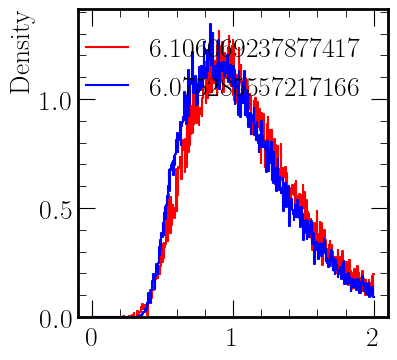

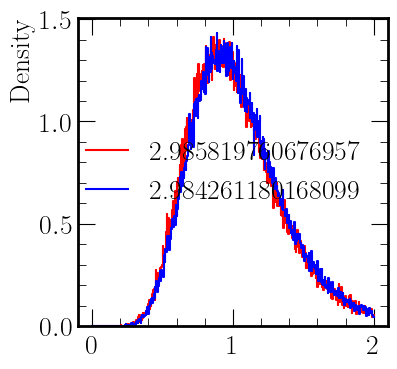

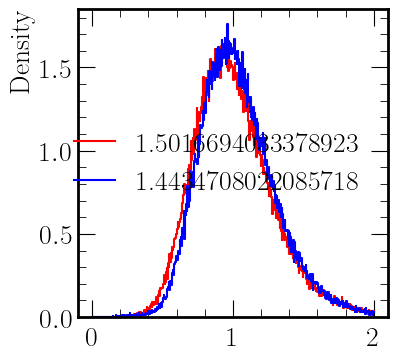

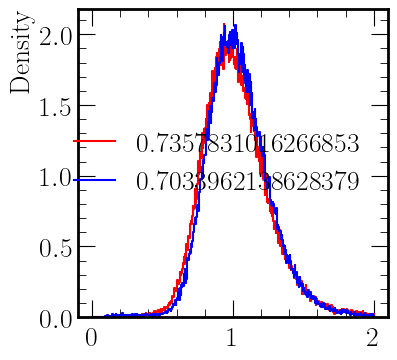

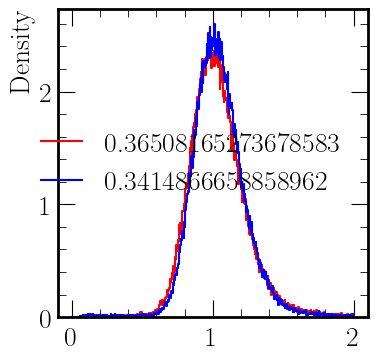

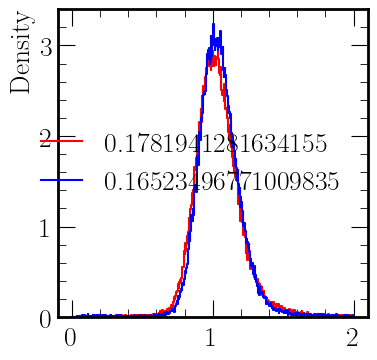

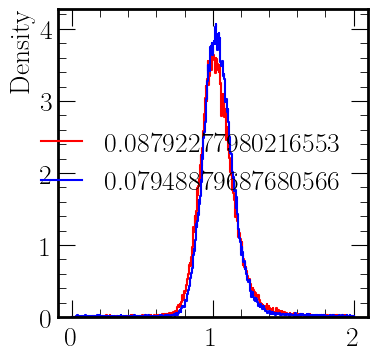

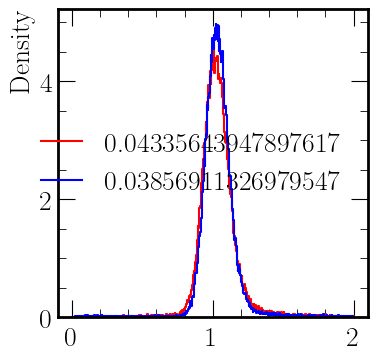

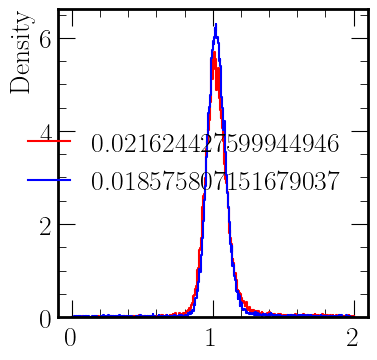

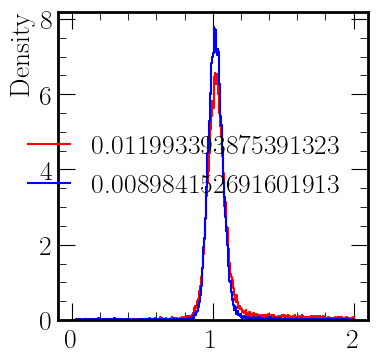

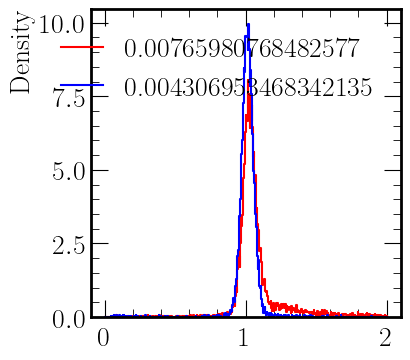

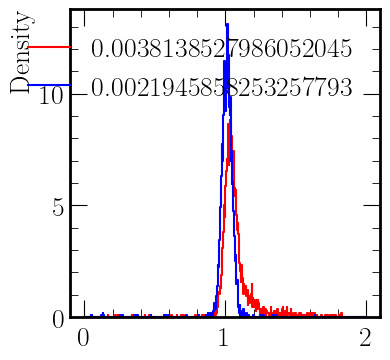

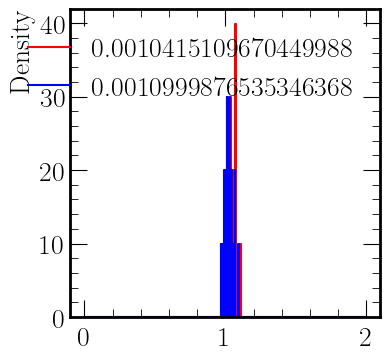

In [115]:
# number_binslen(np.exp(np.arange(np.log(0.5), np.log(60), 1)))
number_dist = len(photons_dic["distributions_pandora"])
import seaborn as sns
for i in range(number_dist):
    vars_p = photons_dic["variance_om_p"] / photons_dic["energy_resolutions_p"]
    vars = photons_dic["variance_om"] / photons_dic["energy_resolutions"]
    fig = plt.figure(figsize=(4,4))
    sns.histplot(photons_dic["distributions_pandora"][i], stat="density", bins= np.linspace(0, 2, 500), element="step", fill=False, color="red", label=str(vars_p[i]))
    sns.histplot(photons_dic["distributions_model"][i], stat="density", bins= np.linspace(0, 2, 500), element="step", fill=False, color="blue", label=str(vars[i]))
    # photons_dic2["distributions_model"]
    plt.legend()
    PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
    PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

    # fig.savefig(os.path.join(PATH_store, "photons1_"+str(i)+".png"), bbox_inches="tight")


In [27]:
print("PID:211___________________________________________")
matched_pandora_h = sd_pandora[(np.abs(sd_pandora.pid)==211)+(np.abs(sd_pandora.pid)==2212)]
matched_h = sd_hgb[(np.abs(sd_hgb.pid)==211)+(np.abs(sd_hgb.pid)==2212)]
matched_pandora_hadron= matched_pandora_h[(matched_pandora_h.pandora_pid==211).values*(matched_h.pred_pid_matched==1).values]
matched_hadron = matched_h[(matched_h.pred_pid_matched==1).values*(matched_pandora_h.pandora_pid==211).values]
# matched_hadron["calibrated_E"]= np.sqrt((matched_hadron["calibrated_E"])**2+(1.3957018E-01**2))
hadrons_dic2 = get_response_for_id_i(
    [211], matched_pandora_hadron, matched_hadron, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
)



PID:211___________________________________________


/tmp/mgarciam/ipykernel_2712624/3685279351.py:2: UserWarning: evaluating in Python space because the '+' operator is not supported by numexpr for the bool dtype, use '|' instead.
  matched_pandora_h = sd_pandora[(np.abs(sd_pandora.pid)==211)+(np.abs(sd_pandora.pid)==2212)]
/tmp/mgarciam/ipykernel_2712624/3685279351.py:3: UserWarning: evaluating in Python space because the '+' operator is not supported by numexpr for the bool dtype, use '|' instead.
  matched_h = sd_hgb[(np.abs(sd_hgb.pid)==211)+(np.abs(sd_hgb.pid)==2212)]


0.22255409284924696 0.2718281828459048 12 0.48100684523582454
0.2718281828459048 0.3320116922736552 15 1.4558600354194637
0.3320116922736552 0.40551999668446803 638 0.02503608107566835
0.40551999668446803 0.49530324243951235 3095 0.020720216035842953
0.49530324243951235 0.6049647464412957 5086 0.015043431520462058
0.6049647464412957 0.7389056098930665 7110 0.01214963078498843
0.7389056098930665 0.902501349943414 11187 0.008922262191772445
0.902501349943414 1.1023176380641628 12519 0.007943037748336768
1.1023176380641628 1.3463738035001724 12901 0.007551521062850952
1.3463738035001724 1.6444646771097096 12838 0.007197449207305917
1.6444646771097096 2.0085536923187726 12775 0.007141846418380726
2.0085536923187726 2.4532530197109423 13007 0.006920526027679452
2.4532530197109423 2.9964100047397113 12918 0.0069759178161620805
2.9964100047397113 3.6598234443678113 12922 0.006942540407180786
3.6598234443678113 4.470118449330099 12640 0.0067927992343902455
4.470118449330099 5.459815003314445 1

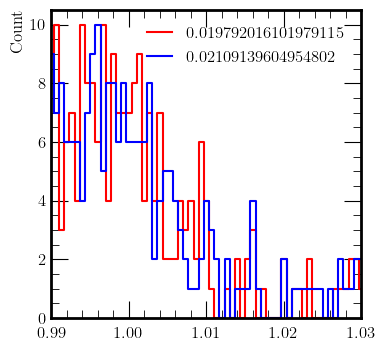

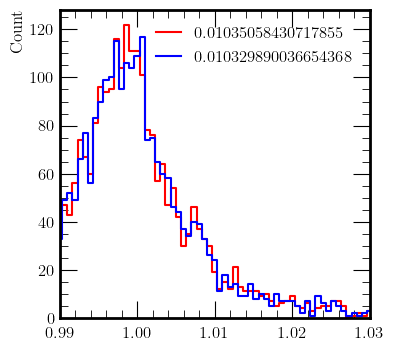

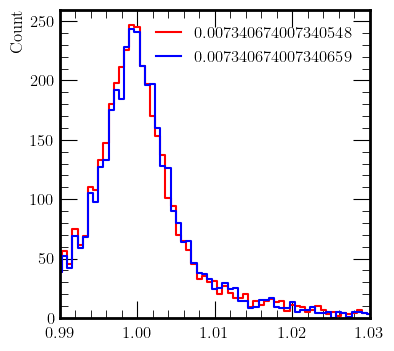

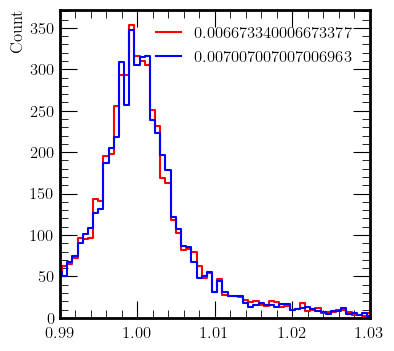

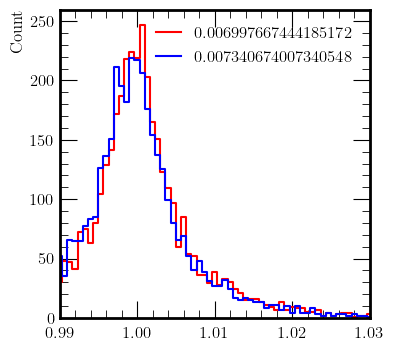

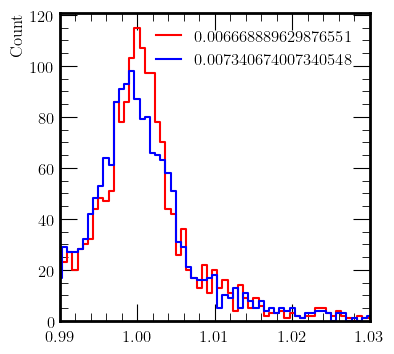

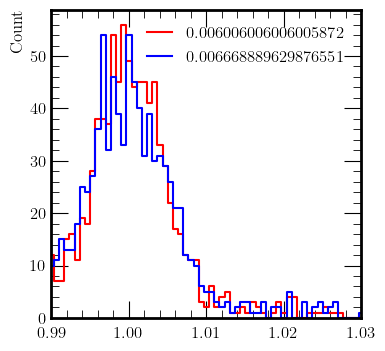

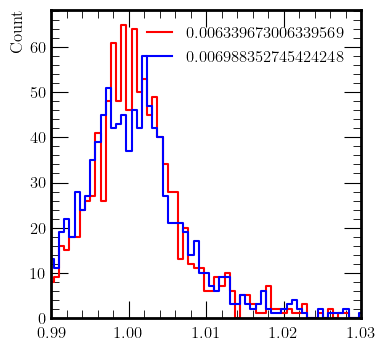

In [13]:
# number_binslen(np.exp(np.arange(np.log(0.5), np.log(60), 1)))
number_dist = len(hadrons_dic2["distributions_pandora"])
import seaborn as sns
for i in range(number_dist):
    vars_p = np.array(hadrons_dic2["variance_om_p"])/np.array(hadrons_dic2["mean_p"])
    vars = np.array(hadrons_dic2["variance_om"])/np.array(hadrons_dic2["mean"])
    fig = plt.figure(figsize=(4,4))
    sns.histplot(hadrons_dic2["distributions_pandora"][i],  bins= np.linspace(0, 2, 3000), element="step", fill=False, color="red", label=str(vars_p[i]))
    sns.histplot(hadrons_dic2["distributions_model"][i], bins= np.linspace(0, 2, 3000), element="step", fill=False, color="blue", label=str(vars[i]))
    # photons_dic2["distributions_model"]
    plt.xlim([0.99,1.03])
    plt.legend()
    PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
    PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

    # fig.savefig(os.path.join(PATH_store, "hadrons_dic1_"+str(i)+".png"), bbox_inches="tight")


In [28]:
matched_pandora_h = sd_pandora[(np.abs(sd_pandora.pid)==2112)+(np.abs(sd_pandora.pid)==130)]
matched_h = sd_hgb[(np.abs(sd_hgb.pid)==2112)+(np.abs(sd_hgb.pid)==130)]
matched_pandora_hadron= matched_pandora_h[(matched_pandora_h.pandora_pid==2112).values*(matched_h.pred_pid_matched==2).values]
matched_hadron = matched_h[(matched_h.pred_pid_matched==2).values*(matched_pandora_h.pandora_pid==2112).values]
neutrons = get_response_for_id_i(
    [2112], matched_pandora_hadron, matched_hadron, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
)

/tmp/mgarciam/ipykernel_2712624/2115458877.py:1: UserWarning: evaluating in Python space because the '+' operator is not supported by numexpr for the bool dtype, use '|' instead.
  matched_pandora_h = sd_pandora[(np.abs(sd_pandora.pid)==2112)+(np.abs(sd_pandora.pid)==130)]
/tmp/mgarciam/ipykernel_2712624/2115458877.py:2: UserWarning: evaluating in Python space because the '+' operator is not supported by numexpr for the bool dtype, use '|' instead.
  matched_h = sd_hgb[(np.abs(sd_hgb.pid)==2112)+(np.abs(sd_hgb.pid)==130)]
/tmp/mgarciam/ipykernel_2712624/1757681705.py:146: RuntimeWarning: invalid value encountered in sqrt
  pred_pxyz = np.sqrt(p_squared).reshape(-1, 1) * pred_pxyz


0.902501349943414 1.1023176380641628 353 0.49078908681869504
1.1023176380641628 1.3463738035001724 2436 0.7937295496463777
1.3463738035001724 1.6444646771097096 2486 0.7810383498668674
1.6444646771097096 2.0085536923187726 2758 0.6684857594966889
2.0085536923187726 2.4532530197109423 2580 0.5940688318014145
2.4532530197109423 2.9964100047397113 2280 0.5402445286512375
2.9964100047397113 3.6598234443678113 2044 0.4990216624736786
3.6598234443678113 4.470118449330099 1857 0.4413496828079224
4.470118449330099 5.459815003314445 1714 0.4001754593849182
5.459815003314445 6.668633104092541 1724 0.3512169575691223
6.668633104092541 8.145086866496845 1558 0.3306442618370056
8.145086866496845 9.948431564193424 1492 0.34679979324340837
9.948431564193424 12.151041751873542 1499 0.3853481984138488
12.151041751873542 14.841315910257729 1509 0.4777363717556001
14.841315910257729 18.127224187515207 1555 0.4319466602802275
18.127224187515207 22.14064162041882 1449 0.3563662528991698
22.14064162041882 2

In [62]:
# print("PID:neutron___________________________________________")
# # matched_pandora_n = sd_pandora1[(np.abs(sd_pandora1.pid_4_class_true)==2)]
# # matched_n = sd_hgb1[(np.abs(sd_hgb1.pid_4_class_true)==2)]
# # matched_pandora_neutral = matched_pandora_n[(matched_pandora_h.pandora_pid==2112)*(matched_n.pred_pid_matched==2)]
# # matched_neutral = matched_n[(matched_n.pred_pid_matched==2)*(matched_pandora_h.pandora_pid==2112)]
# matched_pandora = sd_pandora1
# matched_ = sd_hgb1
# mask = (matched_.pred_pid_matched==2)*(matched_.true_showers_E<0.5)
# matched_.loc[mask, "calibrated_E"] =matched_[(matched_.pred_pid_matched==2)*(matched_.true_showers_E<0.5)].pred_showers_E
# neutrons = get_response_for_id_i(
#     [2112], matched_pandora[np.abs(matched_pandora.pandora_pid)==2112], matched_[matched_.pred_pid_matched==2], tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
# )

# neutrons = get_response_for_id_i(
#     [2112], matched_pandora_neutral, matched_neutral, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
# )

IndexError: list index out of range

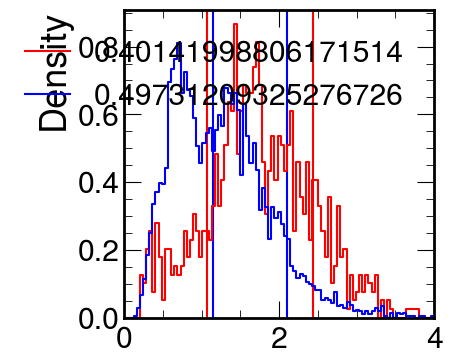

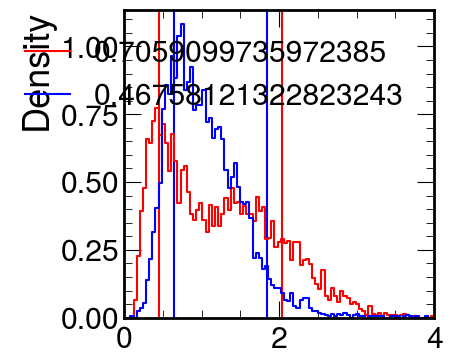

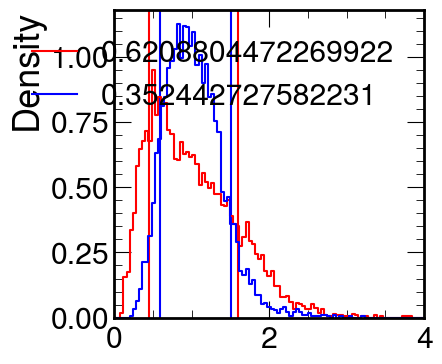

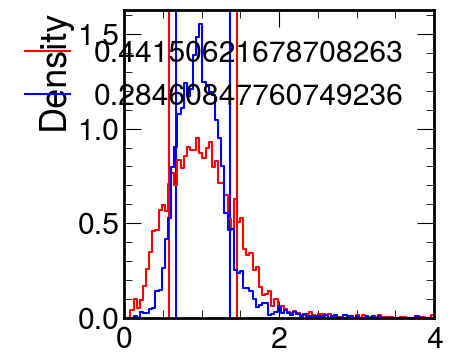

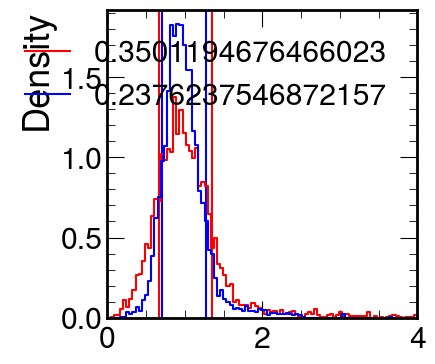

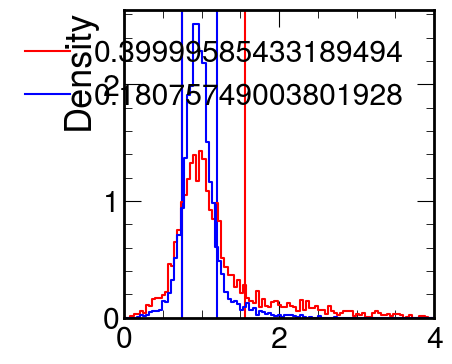

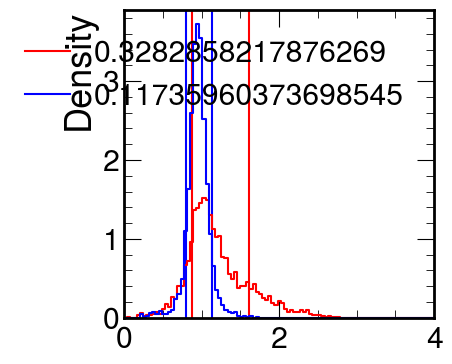

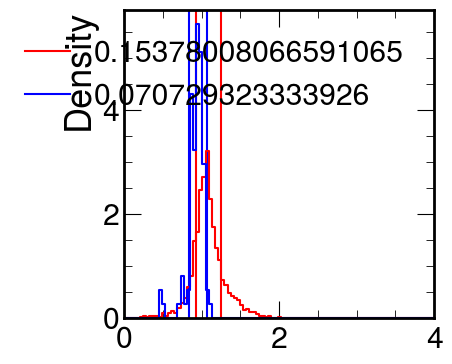

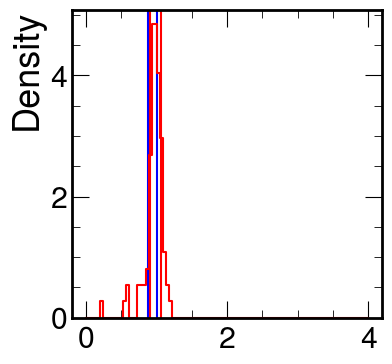

In [12]:
# number_binslen(np.exp(np.arange(np.log(0.5), np.log(60), 1)))
number_dist = len(neutrons["distributions_pandora"])
import seaborn as sns
for i in range(number_dist):
    p16p = np.percentile(neutrons["distributions_pandora"][i], 16)
    p84p = np.percentile(neutrons["distributions_pandora"][i], 84)
    p16 = np.percentile(neutrons["distributions_model"][i], 16)
    p84 = np.percentile(neutrons["distributions_model"][i], 84)
    vars_p = 0.5*np.array(neutrons["variance_om_p"]) / np.array(neutrons["mean_p"])
    vars = 0.5*np.array(neutrons["variance_om"]) / np.array(neutrons["mean"])
    fig = plt.figure(figsize=(4,4))
    plt.axvline(x=p16p, color='r', linestyle='-',)
    plt.axvline(x=p84p, color='r', linestyle='-',)
    plt.axvline(x=p16, color='b', linestyle='-',)
    plt.axvline(x=p84, color='b', linestyle='-',)
    sns.histplot(neutrons["distributions_pandora"][i], stat="density", bins= np.linspace(0, 4, 100), element="step", fill=False, color="red", label=str(vars_p[i]))
    sns.histplot(neutrons["distributions_model"][i+1], stat="density", bins= np.linspace(0, 4, 100), element="step", fill=False, color="blue", label=str(vars[i+1]))
    # photons_dic2["distributions_model"]
    plt.xlim([0,4])
    plt.legend()
    PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
    PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

    fig.savefig(os.path.join(PATH_store, "neutrons1_"+str(i)+".png"), bbox_inches="tight")

In [29]:
from matplotlib.patches import Rectangle
def plot_error_bars2(
    photons_dic,
    ax,
    bins, 
    facecolor="#E36414",
    alpha=0.6,
):
    bins = np.array(bins)
    eff = np.array(0.5*np.array(photons_dic["variance_om"]) / np.array(photons_dic["mean"]))
    error_y = np.array(photons_dic["variance_errors"])
    yerr_lower = error_y/2
    yerr_upper = error_y/2

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - yerr_lower[j]
        height = yerr_lower[j] + yerr_upper[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=None,
            alpha=alpha,
        )
        ax.add_patch(rect)



def plot_error_bars_pandora2(
    photons_dic,
    ax,
    bins,
    i=0,
    facecolor="#0F4C5C",
    alpha=0.6,
    edgecolor=None,
):
    bins = np.array(bins)
    eff = np.array(0.5*np.array(photons_dic["variance_om_p"]) / np.array(photons_dic["mean_p"]))
    error_y = np.array(photons_dic["variance_errors_p"])
    yerr_lower = error_y/2
    yerr_upper = error_y/2

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - yerr_lower[j]
        height = yerr_lower[j] + yerr_upper[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

    # Optional: center markers
    # bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # ax.plot(bin_centers, eff, "o", color=facecolor)

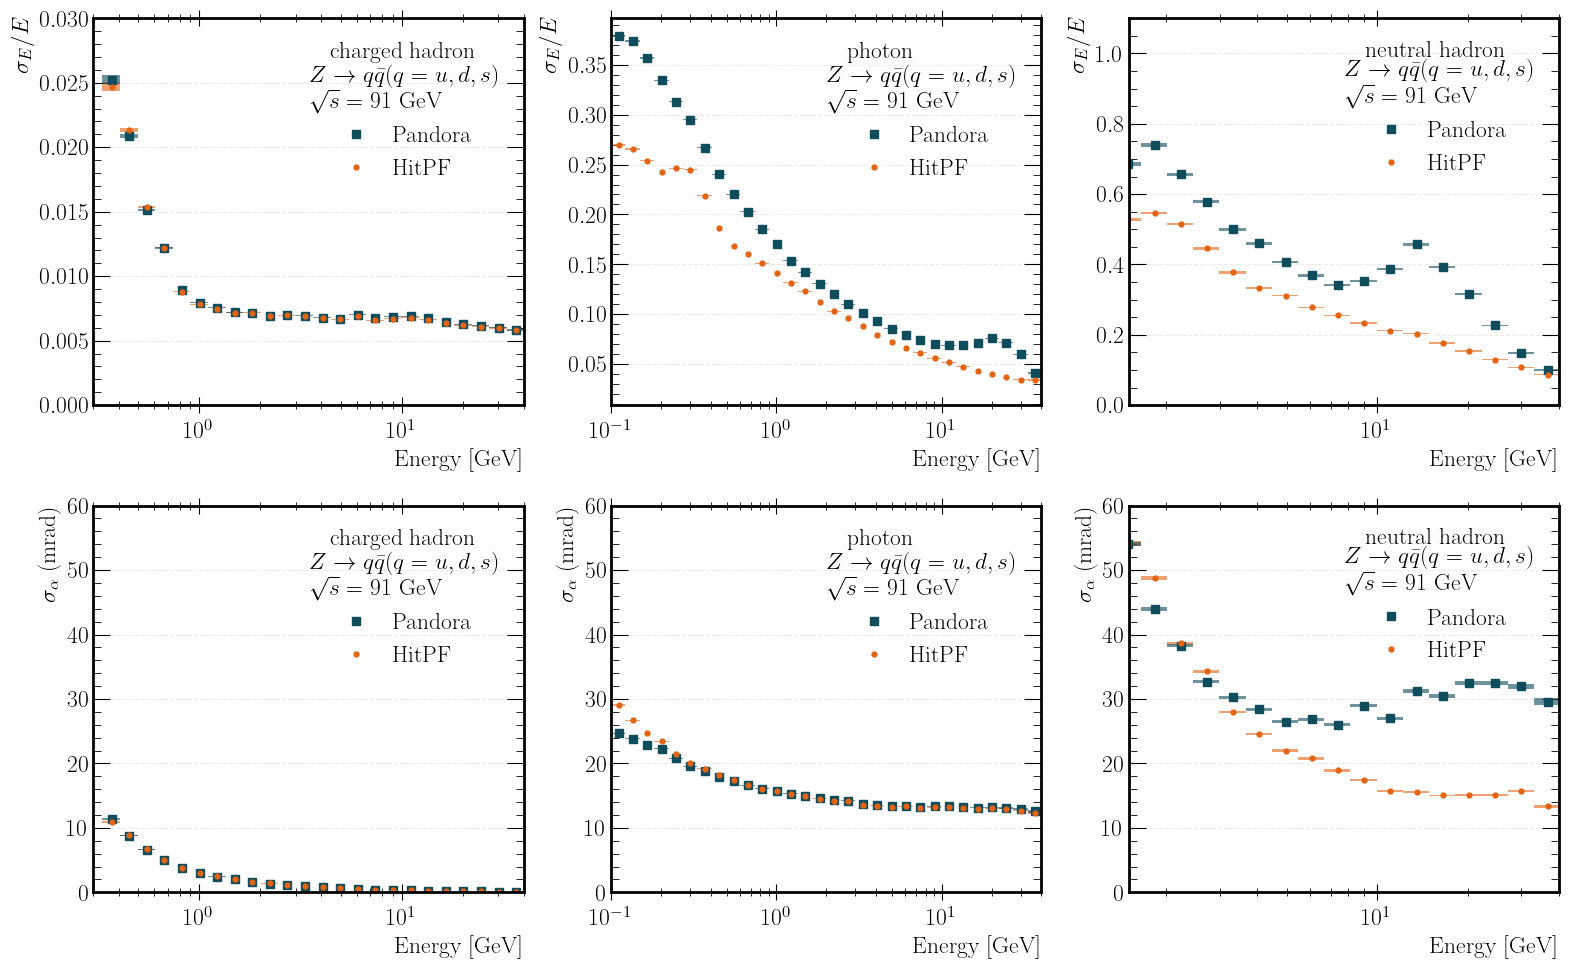

In [31]:
### E resolution with PID
photon_edir = photons_dic
ch_edir = hadrons_dic2
nh_edir = neutrons
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
size_font = 17

STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=7) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='s', linestyle='None', markersize=6)
fig, ax_eff = plt.subplots(2, 3,figsize=(16, 10))
bins = [0, 5, 15, 50]
bin_labels = [f"[{bins[i]},{bins[i + 1]}]" for i in range(len(bins) - 1)]
ax_eff[0,1].plot(photon_edir["energy_resolutions_p"], 0.5*np.array(photon_edir["variance_om_p"]) / np.array(photon_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0,1].plot(photon_edir["energy_resolutions"],0.5*np.array(photon_edir["variance_om"]) / np.array(photon_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[0,1].set_xlabel("Energy [GeV]")
ax_eff[0,1].set_ylabel("$\sigma_E / E$")
ax_eff[0,1].set_xticks([2.5, 10.0, 33.0])
ax_eff[0,1].set_xlim([1e-1,40])
ax_eff[0,1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0,1].tick_params(axis='x', which='both', direction='inout')
ax_eff[0,1].legend(fontsize = size_font, title_fontsize=size_font, title=r"photon \\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
plot_error_bars2(photon_edir, ax_eff[0,1], np.exp(np.arange(np.log(0.1), np.log(80), 0.2)))
plot_error_bars_pandora2(photon_edir, ax_eff[0,1], np.exp(np.arange(np.log(0.1), np.log(80), 0.2)))

ax_eff[0,0].plot(ch_edir["energy_resolutions_p"], 0.5*np.array(ch_edir["variance_om_p"]) / np.array(ch_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0,0].plot(ch_edir["energy_resolutions"],0.5*np.array(ch_edir["variance_om"])/ np.array(ch_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[0,0].set_xlabel("Energy [GeV]")
ax_eff[0,0].set_ylabel("$\sigma_E / E$")
ax_eff[0,0].set_xticks([2.5, 10.0, 33.0])
ax_eff[0,0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0,0].tick_params(axis='x', which='both', direction='inout')
ax_eff[0,0].set_xlim([0.3,40])
ax_eff[0,0].set_ylim([0,0.03])
ax_eff[0,0].legend(fontsize = size_font, title_fontsize=size_font, title=r"charged hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$\\  $\sqrt s=$ 91 GeV", loc="upper right")
plot_error_bars2(ch_edir, ax_eff[0,0], np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[4:])
plot_error_bars_pandora2(ch_edir, ax_eff[0,0], np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[4:])

ax_eff[0,2].plot(nh_edir["energy_resolutions_p"], 0.5*np.array(nh_edir["variance_om_p"]) / np.array(nh_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0,2].plot(nh_edir["energy_resolutions"],0.5*np.array(nh_edir["variance_om"]) / np.array(nh_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[0,2].set_xlabel("Energy [GeV]")
ax_eff[0,2].set_ylabel("$\sigma_E / E$")
ax_eff[0,2].set_xticks([2.5, 10.0, 33.0])
ax_eff[0,2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0,2].tick_params(axis='x', which='both', direction='inout')
plot_error_bars2(nh_edir, ax_eff[0,2],  np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[11:])
plot_error_bars_pandora2(nh_edir, ax_eff[0,2],  np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[11:])
ax_eff[0,2].legend(fontsize = size_font, title_fontsize=size_font, title=r"neutral hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
ax_eff[0,2].set_xlim([1.5,40])
ax_eff[0,2].set_ylim([0,1.1])


ax_eff[1,1].plot(photon_edir["energy_resolutions_p"], 1000*np.array(photon_edir["sigma_phi_pandora"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1,1].plot(photon_edir["energy_resolutions"],1000*np.array(photon_edir["sigma_phi"]), label="HitPF", **STYLE_OURS)
ax_eff[1,1].set_xlabel("Energy [GeV]")
ax_eff[1,1].set_ylabel(r"$\sigma_{ \alpha}$ (mrad)")
ax_eff[1,1].set_xticks([2.5, 10.0, 33.0])
ax_eff[1,1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1,1].tick_params(axis='x', which='both', direction='inout')
ax_eff[1,1].legend(fontsize = size_font, title_fontsize=size_font, title=r"photon \\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
ax_eff[1,1].set_xlim([1e-1,40])
ax_eff[1,1].set_ylim([0,60])
ax_eff[1,0].plot(ch_edir["energy_resolutions_p"], 1000*np.array(ch_edir["sigma_phi_pandora"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")
plot_error_bars3(photon_edir, ax_eff[1,1], np.exp(np.arange(np.log(0.1), np.log(80), 0.2)))
plot_error_bars_pandora3(photon_edir, ax_eff[1,1], np.exp(np.arange(np.log(0.1), np.log(80), 0.2)))

ax_eff[1,0].plot(ch_edir["energy_resolutions"],1000*np.array(ch_edir["sigma_phi"]), label="HitPF", **STYLE_OURS)
ax_eff[1,0].set_xlabel("Energy [GeV]")
ax_eff[1,0].set_ylabel(r"$\sigma_{ \alpha}$ (mrad)")
ax_eff[1,0].set_xticks([2.5, 10.0, 33.0])
ax_eff[1,0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1,0].tick_params(axis='x', which='both', direction='inout')
ax_eff[1,0].set_xlim([0.3,40])
ax_eff[1,0].set_ylim([0,60])
ax_eff[1,0].legend(fontsize = size_font, title_fontsize=size_font, title=r"charged hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$\\  $\sqrt s=$ 91 GeV", loc="upper right")
plot_error_bars3(ch_edir, ax_eff[1,0], np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[4:])
plot_error_bars_pandora3(ch_edir, ax_eff[1,0], np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[4:])
ax_eff[1,2].plot(nh_edir["energy_resolutions_p"], 1000*np.array(nh_edir["sigma_phi_pandora"]) , **STYLE_PANDORA,label="Pandora")
# ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1,2].plot(nh_edir["energy_resolutions"],1000*np.array(nh_edir["sigma_phi"]) , label="HitPF", **STYLE_OURS)
ax_eff[1,2].set_xlabel("Energy [GeV]")
ax_eff[1,2].set_ylabel(r"$\sigma_{ \alpha}$ (mrad)")
ax_eff[1,2].set_xticks([2.5, 10.0, 33.0])
ax_eff[1,2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1,2].tick_params(axis='x', which='both', direction='inout')

ax_eff[1,2].legend(fontsize = size_font, title_fontsize=size_font, title=r"neutral hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
ax_eff[1,2].set_xlim([1.5,40])
ax_eff[1,2].set_ylim([0,60])
plot_error_bars3(nh_edir, ax_eff[1,2], np.exp(np.arange(np.log(0.1), np.log(80), 0.2))[11:])
plot_error_bars_pandora3(nh_edir, ax_eff[1,2], np.exp(np.arange(np.log(0.1), np.log(80),0.2))[11:])


for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    # ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
    # ax.set_xlim([0.5,70])
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "e_angular_resolution.pdf"), bbox_inches="tight")

IndexError: index 23 is out of bounds for axis 0 with size 23

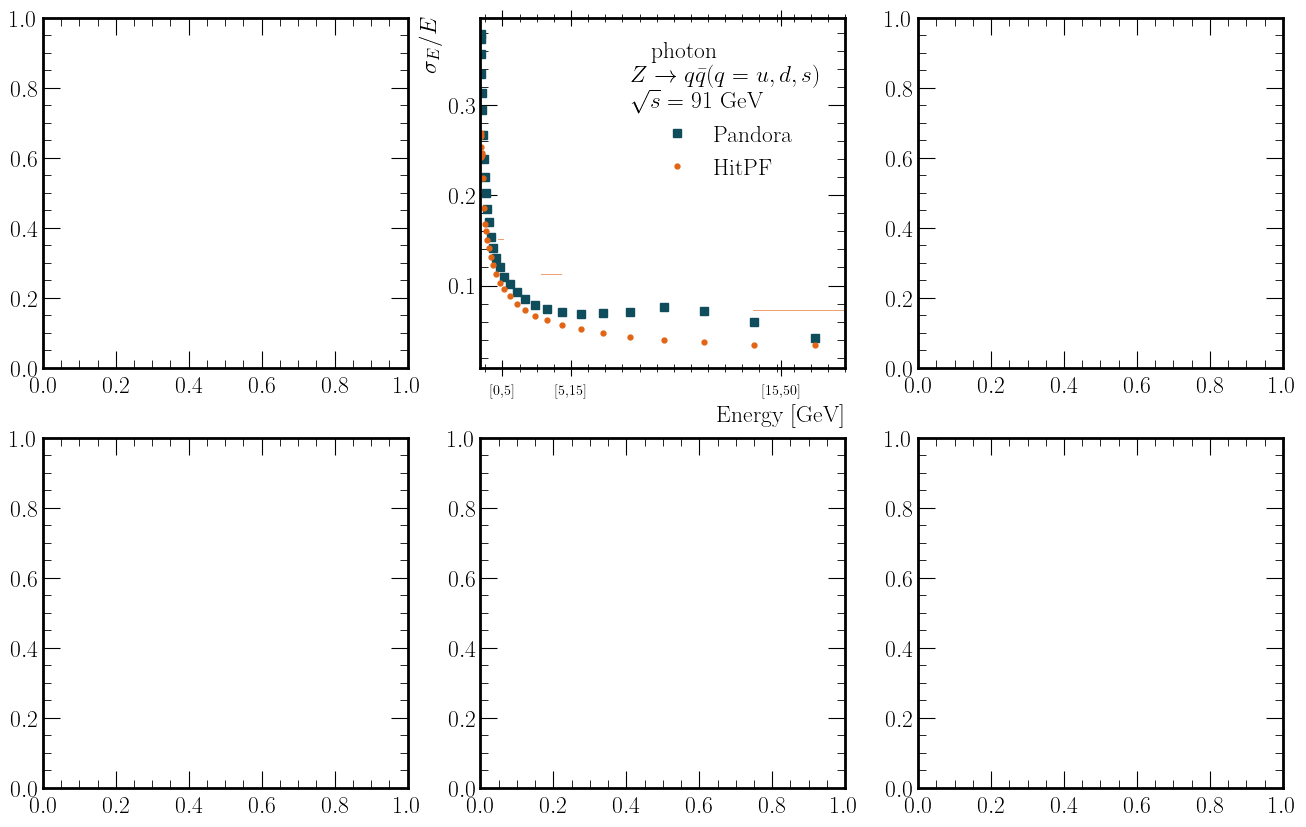

In [20]:
### E resolution with PID
photon_edir = photons_dic
ch_edir = hadrons_dic2
nh_edir = neutrons
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
size_font = 17

STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=7) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='s', linestyle='None', markersize=6)
fig, ax_eff = plt.subplots(2, 3,figsize=(16, 10))
bins = [0, 5, 15, 50]
bin_labels = [f"[{bins[i]},{bins[i + 1]}]" for i in range(len(bins) - 1)]
ax_eff[0,1].plot(photon_edir["energy_resolutions_p"], 0.5*np.array(photon_edir["variance_om_p"]) / np.array(photon_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0,1].plot(photon_edir["energy_resolutions"],0.5*np.array(photon_edir["variance_om"]) / np.array(photon_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[0,1].set_xlabel("Energy [GeV]")
ax_eff[0,1].set_ylabel("$\sigma_E / E$")
ax_eff[0,1].set_xticks([2.5, 10.0, 33.0])
ax_eff[0,1].set_xlim([1e-1,40])
ax_eff[0,1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0,1].tick_params(axis='x', which='both', direction='inout')
ax_eff[0,1].legend(fontsize = size_font, title_fontsize=size_font, title=r"photon \\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
plot_error_bars2(photon_edir, ax_eff[0,1], np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
plot_error_bars_pandora2(photon_edir, ax_eff[0,1], np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))

ax_eff[0,0].plot(ch_edir["energy_resolutions_p"], 0.5*np.array(ch_edir["variance_om_p"]) / np.array(ch_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0,0].plot(ch_edir["energy_resolutions"],0.5*np.array(ch_edir["variance_om"])/ np.array(ch_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[0,0].set_xlabel("Energy [GeV]")
ax_eff[0,0].set_ylabel("$\sigma_E / E$")
ax_eff[0,0].set_xticks([2.5, 10.0, 33.0])
ax_eff[0,0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0,0].tick_params(axis='x', which='both', direction='inout')
ax_eff[0,0].set_xlim([0.3,40])
ax_eff[0,0].set_ylim([0,0.03])
ax_eff[0,0].legend(fontsize = size_font, title_fontsize=size_font, title=r"charged hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$\\  $\sqrt s=$ 91 GeV", loc="upper right")
plot_error_bars2(ch_edir, ax_eff[0,0], np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[2:])
plot_error_bars_pandora2(ch_edir, ax_eff[0,0], np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[2:])

ax_eff[0,2].plot(nh_edir["energy_resolutions_p"], 0.5*np.array(nh_edir["variance_om_p"]) / np.array(nh_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0,2].plot(nh_edir["energy_resolutions"],0.5*np.array(nh_edir["variance_om"]) / np.array(nh_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[0,2].set_xlabel("Energy [GeV]")
ax_eff[0,2].set_ylabel("$\sigma_E / E$")
ax_eff[0,2].set_xticks([2.5, 10.0, 33.0])
ax_eff[0,2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0,2].tick_params(axis='x', which='both', direction='inout')
plot_error_bars2(nh_edir, ax_eff[0,2],  np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[7:])
plot_error_bars_pandora2(nh_edir, ax_eff[0,2],  np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[7:])
ax_eff[0,2].legend(fontsize = size_font, title_fontsize=size_font, title=r"neutral hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
ax_eff[0,2].set_xlim([1.5,40])
ax_eff[0,2].set_ylim([0,1.1])


ax_eff[1,1].plot(photon_edir["energy_resolutions_p"], 1000*np.array(photon_edir["sigma_phi_pandora"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1,1].plot(photon_edir["energy_resolutions"],1000*np.array(photon_edir["sigma_phi"]), label="HitPF", **STYLE_OURS)
ax_eff[1,1].set_xlabel("Energy [GeV]")
ax_eff[1,1].set_ylabel(r"$\sigma_{\Delta \alpha}$ (mrad)")
ax_eff[1,1].set_xticks([2.5, 10.0, 33.0])
ax_eff[1,1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1,1].tick_params(axis='x', which='both', direction='inout')
ax_eff[1,1].legend(fontsize = size_font, title_fontsize=size_font, title=r"photon \\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
ax_eff[1,1].set_xlim([1e-1,40])
ax_eff[1,1].set_ylim([0,60])
ax_eff[1,0].plot(ch_edir["energy_resolutions_p"], 1000*np.array(ch_edir["sigma_phi_pandora"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")
plot_error_bars3(photon_edir, ax_eff[1,1], np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
plot_error_bars_pandora3(photon_edir, ax_eff[1,1], np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))

ax_eff[1,0].plot(ch_edir["energy_resolutions"],1000*np.array(ch_edir["sigma_phi"]), label="HitPF", **STYLE_OURS)
ax_eff[1,0].set_xlabel("Energy [GeV]")
ax_eff[1,0].set_ylabel(r"$\sigma_{\Delta \alpha}$ (mrad)")
ax_eff[1,0].set_xticks([2.5, 10.0, 33.0])
ax_eff[1,0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1,0].tick_params(axis='x', which='both', direction='inout')
ax_eff[1,0].set_xlim([0.3,40])
ax_eff[1,0].set_ylim([0,60])
ax_eff[1,0].legend(fontsize = size_font, title_fontsize=size_font, title=r"charged hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$\\  $\sqrt s=$ 91 GeV", loc="upper right")
plot_error_bars3(ch_edir, ax_eff[1,0], np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[2:])
plot_error_bars_pandora3(ch_edir, ax_eff[1,0], np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[2:])
ax_eff[1,2].plot(nh_edir["energy_resolutions_p"], 1000*np.array(nh_edir["sigma_phi_pandora"]) , **STYLE_PANDORA,label="Pandora")
# ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1,2].plot(nh_edir["energy_resolutions"],1000*np.array(nh_edir["sigma_phi"]) , label="HitPF", **STYLE_OURS)
ax_eff[1,2].set_xlabel("Energy [GeV]")
ax_eff[1,2].set_ylabel(r"$\sigma_{\Delta \alpha}$ (mrad)")
ax_eff[1,2].set_xticks([2.5, 10.0, 33.0])
ax_eff[1,2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1,2].tick_params(axis='x', which='both', direction='inout')

ax_eff[1,2].legend(fontsize = size_font, title_fontsize=size_font, title=r"neutral hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
ax_eff[1,2].set_xlim([1.5,40])
ax_eff[1,2].set_ylim([0,60])
plot_error_bars3(nh_edir, ax_eff[1,2], np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[7:])
plot_error_bars_pandora3(nh_edir, ax_eff[1,2], np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[7:])


for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    # ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
    # ax.set_xlim([0.5,70])
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "e_resolution_more_data_v05_same_data_new_data_s17.pdf"), bbox_inches="tight")


In [85]:
from matplotlib.patches import Rectangle
def plot_error_bars2(
    photons_dic,
    ax,
    bins, 
    facecolor="#E36414",
    alpha=0.6,
):
    bins = np.array(bins)
    eff = np.array(np.array(photons_dic["sigma_theta"]))
    error_y = np.array(photons_dic["sigma_errors_theta"])
    yerr_lower = error_y/2
    yerr_upper = error_y/2

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - yerr_lower[j]
        height = yerr_lower[j] + yerr_upper[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=None,
            alpha=alpha,
        )
        ax.add_patch(rect)



def plot_error_bars_pandora2(
    photons_dic,
    ax,
    bins,
    i=0,
    facecolor="#0F4C5C",
    alpha=0.6,
    edgecolor=None,
):
    bins = np.array(bins)
    eff = np.array(np.array(photons_dic["sigma_theta_pandora"]) )
    error_y = np.array(photons_dic["sigma_errors_theta_pandora"])
    yerr_lower = error_y/2
    yerr_upper = error_y/2

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - yerr_lower[j]
        height = yerr_lower[j] + yerr_upper[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

    # Optional: center markers
    # bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # ax.plot(bin_centers, eff, "o", color=facecolor)

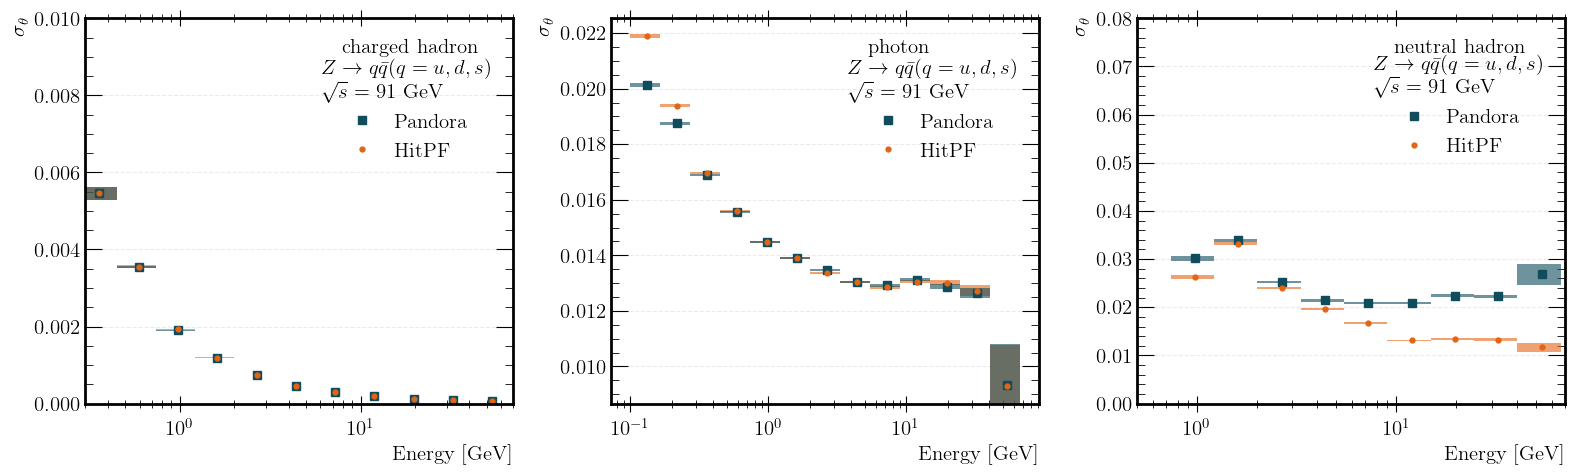

In [86]:
### E resolution with PID
photon_edir = photons_dic
ch_edir = hadrons_dic2
nh_edir = neutrons
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
size_font = 15

STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=7) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='s', linestyle='None', markersize=6)
fig, ax_eff = plt.subplots(1, 3,figsize=(16, 5))
bins = [0, 5, 15, 50]
bin_labels = [f"[{bins[i]},{bins[i + 1]}]" for i in range(len(bins) - 1)]
ax_eff[1].plot(photon_edir["energy_resolutions_p"], np.array(photon_edir["sigma_theta_pandora"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1].plot(photon_edir["energy_resolutions"],np.array(photon_edir["sigma_theta"]), label="HitPF", **STYLE_OURS)
ax_eff[1].set_xlabel("Energy [GeV]")
ax_eff[1].set_ylabel(r"$\sigma_{\theta}$")
ax_eff[1].set_xticks([2.5, 10.0, 33.0])
ax_eff[1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1].tick_params(axis='x', which='both', direction='inout')
ax_eff[1].legend(fontsize = size_font, title_fontsize=size_font, title=r"photon \\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
plot_error_bars2(photon_edir, ax_eff[1], np.exp(np.arange(np.log(0.1), np.log(70), 0.5)))
plot_error_bars_pandora2(photon_edir, ax_eff[1], np.exp(np.arange(np.log(0.1), np.log(70), 0.5)))

ax_eff[0].plot(ch_edir["energy_resolutions_p"], np.array(ch_edir["sigma_theta_pandora"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0].plot(ch_edir["energy_resolutions"],np.array(ch_edir["sigma_theta"]), label="HitPF", **STYLE_OURS)
ax_eff[0].set_xlabel("Energy [GeV]")
ax_eff[0].set_ylabel(r"$\sigma_{\theta}$")
ax_eff[0].set_xticks([2.5, 10.0, 33.0])
ax_eff[0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0].tick_params(axis='x', which='both', direction='inout')
ax_eff[0].set_xlim([0.3,70])
ax_eff[0].set_ylim([0,0.005*2])
ax_eff[0].legend(fontsize = size_font, title_fontsize=size_font, title=r"charged hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$\\  $\sqrt s=$ 91 GeV", loc="upper right")
plot_error_bars2(ch_edir, ax_eff[0], np.exp(np.arange(np.log(0.1), np.log(70), 0.5))[1:])
plot_error_bars_pandora2(ch_edir, ax_eff[0], np.exp(np.arange(np.log(0.1), np.log(70), 0.5))[1:])

ax_eff[2].plot(nh_edir["energy_resolutions_p"], np.array(nh_edir["sigma_theta_pandora"]) , **STYLE_PANDORA,label="Pandora")
# ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[2].plot(nh_edir["energy_resolutions"],np.array(nh_edir["sigma_theta"]) , label="HitPF", **STYLE_OURS)
ax_eff[2].set_xlabel("Energy [GeV]")
ax_eff[2].set_ylabel(r"$\sigma_{\theta}$")
ax_eff[2].set_xticks([2.5, 10.0, 33.0])
ax_eff[2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[2].tick_params(axis='x', which='both', direction='inout')
plot_error_bars2(nh_edir, ax_eff[2], np.exp(np.arange(np.log(0.1), np.log(70), 0.5))[4:])
plot_error_bars_pandora2(nh_edir, ax_eff[2], np.exp(np.arange(np.log(0.1), np.log(70), 0.5))[4:])
ax_eff[2].legend(fontsize = size_font, title_fontsize=size_font, title=r"neutral hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
ax_eff[2].set_xlim([0.5,70])
ax_eff[2].set_ylim([0,0.04*2])
for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    # ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
    # ax.set_xlim([0.5,70])
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "theta_resol_more_data_v05_same_data_new_data_s15.pdf"), bbox_inches="tight")

In [30]:
from matplotlib.patches import Rectangle
def plot_error_bars3(
    photons_dic,
    ax,
    bins, 
    facecolor="#E36414",
    alpha=0.6,
):
    bins = np.array(bins)
    eff = 1000*np.array(np.array(photons_dic["sigma_phi"]))
    error_y = 1000*np.array(photons_dic["phi_error"])
    yerr_lower = error_y/2
    yerr_upper = error_y/2

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - yerr_lower[j]
        height = yerr_lower[j] + yerr_upper[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=None,
            alpha=alpha,
        )
        ax.add_patch(rect)



def plot_error_bars_pandora3(
    photons_dic,
    ax,
    bins,
    i=0,
    facecolor="#0F4C5C",
    alpha=0.6,
    edgecolor=None,
):
    bins = np.array(bins)
    eff = 1000*np.array(np.array(photons_dic["sigma_phi_pandora"]) )
    error_y = 1000*np.array(photons_dic["phi_error_p"])
    yerr_lower = error_y/2
    yerr_upper = error_y/2

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - yerr_lower[j]
        height = yerr_lower[j] + yerr_upper[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

    # Optional: center markers
    # bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # ax.plot(bin_centers, eff, "o", color=facecolor)

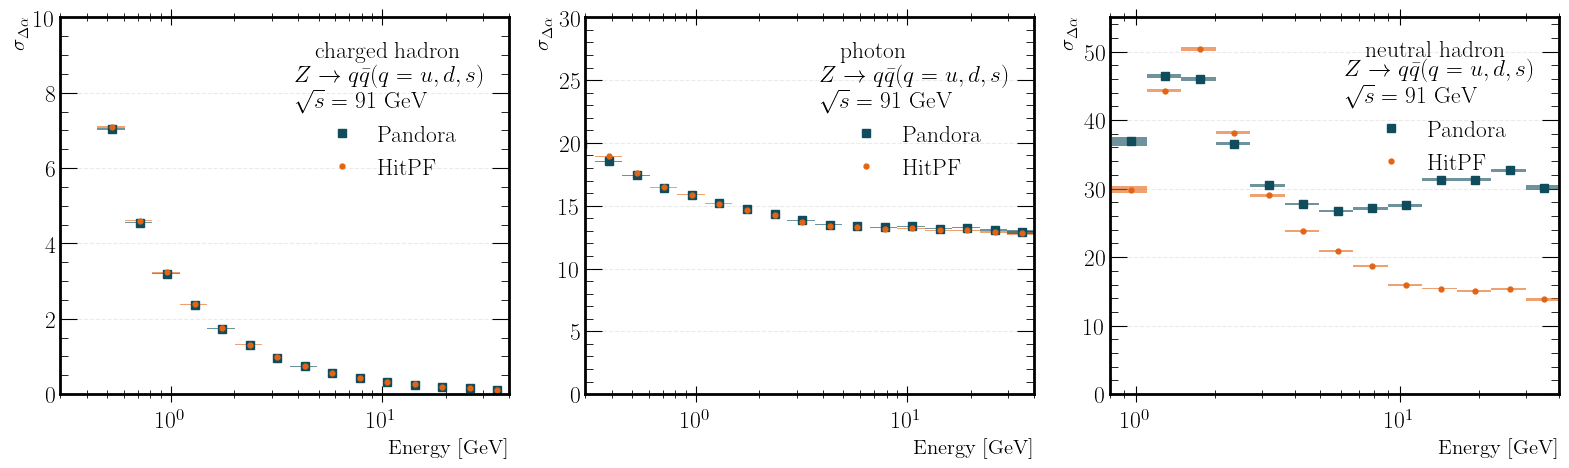

In [53]:
### E resolution with PID
photon_edir = photons_dic
ch_edir = hadrons_dic2
nh_edir = neutrons
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
size_font = 17

STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=7) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='s', linestyle='None', markersize=6)
fig, ax_eff = plt.subplots(1, 3,figsize=(16, 5))
bins = [0, 5, 15, 50]
bin_labels = [f"[{bins[i]},{bins[i + 1]}]" for i in range(len(bins) - 1)]
ax_eff[1].plot(photon_edir["energy_resolutions_p"], 1000*np.array(photon_edir["sigma_phi_pandora"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1].plot(photon_edir["energy_resolutions"],1000*np.array(photon_edir["sigma_phi"]), label="HitPF", **STYLE_OURS)
ax_eff[1].set_xlabel("Energy [GeV]")
ax_eff[1].set_ylabel(r"$\sigma_{\Delta \alpha}$")
ax_eff[1].set_xticks([2.5, 10.0, 33.0])
ax_eff[1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1].tick_params(axis='x', which='both', direction='inout')
ax_eff[1].legend(fontsize = size_font, title_fontsize=size_font, title=r"photon \\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
ax_eff[1].set_xlim([0.3,40])
ax_eff[1].set_ylim([0,30])
ax_eff[0].plot(ch_edir["energy_resolutions_p"], 1000*np.array(ch_edir["sigma_phi_pandora"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")
plot_error_bars2(photon_edir, ax_eff[1], np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))
plot_error_bars_pandora2(photon_edir, ax_eff[1], np.exp(np.arange(np.log(0.1), np.log(80), 0.3)))

ax_eff[0].plot(ch_edir["energy_resolutions"],1000*np.array(ch_edir["sigma_phi"]), label="HitPF", **STYLE_OURS)
ax_eff[0].set_xlabel("Energy [GeV]")
ax_eff[0].set_ylabel(r"$\sigma_{\Delta \alpha}$")
ax_eff[0].set_xticks([2.5, 10.0, 33.0])
ax_eff[0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0].tick_params(axis='x', which='both', direction='inout')
ax_eff[0].set_xlim([0.3,40])
ax_eff[0].set_ylim([0,10])
ax_eff[0].legend(fontsize = size_font, title_fontsize=size_font, title=r"charged hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$\\  $\sqrt s=$ 91 GeV", loc="upper right")
plot_error_bars2(ch_edir, ax_eff[0], np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[2:])
plot_error_bars_pandora2(ch_edir, ax_eff[0], np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[2:])
ax_eff[2].plot(nh_edir["energy_resolutions_p"], 1000*np.array(nh_edir["sigma_phi_pandora"]) , **STYLE_PANDORA,label="Pandora")
# ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[2].plot(nh_edir["energy_resolutions"],1000*np.array(nh_edir["sigma_phi"]) , label="HitPF", **STYLE_OURS)
ax_eff[2].set_xlabel("Energy [GeV]")
ax_eff[2].set_ylabel(r"$\sigma_{\Delta \alpha}$")
ax_eff[2].set_xticks([2.5, 10.0, 33.0])
ax_eff[2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[2].tick_params(axis='x', which='both', direction='inout')

ax_eff[2].legend(fontsize = size_font, title_fontsize=size_font, title=r"neutral hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$ \\ $\sqrt s=$ 91 GeV", loc="upper right")
ax_eff[2].set_xlim([0.8,40])
ax_eff[2].set_ylim([0,55])
plot_error_bars2(nh_edir, ax_eff[2], np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[7:])
plot_error_bars_pandora2(nh_edir, ax_eff[2], np.exp(np.arange(np.log(0.1), np.log(80), 0.3))[7:])
# ax_eff[2].set_ylim([0,0.04])
for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    # ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
    # ax.set_xlim([0.5,70])
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "phi_resol_more_data_v05_same_data_new_data_s15.pdf"), bbox_inches="tight")

In [50]:
nh_edir["energy_resolutions_p"]

array([ 0.95946731,  1.29514541,  1.74826343,  2.35990879,  3.18554367,
        4.30003418,  5.80443901,  7.83517312, 10.57637744, 14.27661624,
       19.27141618, 26.01369086, 35.11480972, 47.40003518])

In [51]:
np.exp(np.arange(np.log(0.1), np.log(80), 0.3))

array([ 0.1       ,  0.13498588,  0.18221188,  0.24596031,  0.33201169,
        0.44816891,  0.60496475,  0.81661699,  1.10231764,  1.48797317,
        2.00855369,  2.71126389,  3.65982344,  4.94024491,  6.6686331 ,
        9.00171313, 12.15104175, 16.40219073, 22.14064162, 29.8867401 ,
       40.34287935, 54.45719101, 73.50951892])

<Axes: ylabel='Density'>

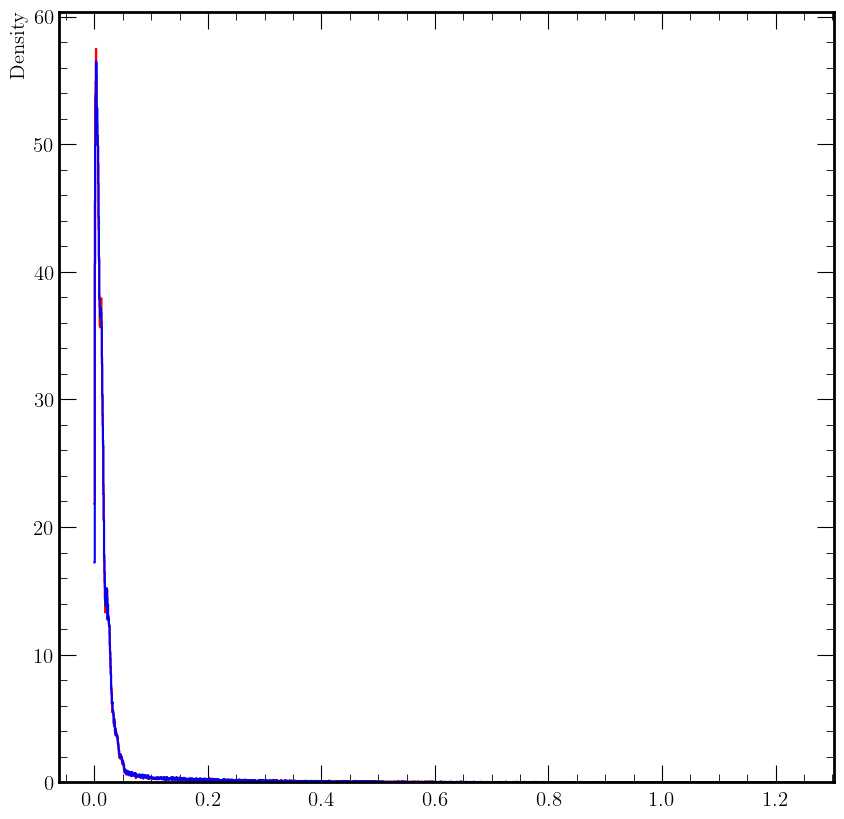

In [123]:
import seaborn as sns
photon_edir = photons_dic
distr_angles_pandora = np.concatenate([photon_edir["distr_angles_pandora"][0],photon_edir["distr_angles_pandora"][1],photon_edir["distr_angles_pandora"][2],photon_edir["distr_angles_pandora"][3],photon_edir["distr_angles_pandora"][4],photon_edir["distr_angles_pandora"][5],photon_edir["distr_angles_pandora"][6]])
distr_angles= np.concatenate([photon_edir["distr_angles"][0],photon_edir["distr_angles"][1],photon_edir["distr_angles"][2],photon_edir["distr_angles"][3],photon_edir["distr_angles"][4],photon_edir["distr_angles"][5],photon_edir["distr_angles"][6]])
sns.histplot(distr_angles_pandora, stat="density", element="step", fill=False, color="red")
sns.histplot(distr_angles, stat="density", element="step", fill=False, color="blue")